# COMP1891 – Applications in AI and Data Science
## Jupyter Notebook Submission

**Module:** COMP1891 | **Module Leader:** Dr Nageena Frost | **University of Greenwich**

## Setup and Imports

In [1]:
import sys
# Install any missing packages (safe to re-run)
# !{sys.executable} -m pip install torch torchvision transformers scikit-learn pandas numpy matplotlib seaborn scipy pillow opencv-python --quiet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from scipy import stats
import warnings, os, glob, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay, silhouette_score,
    balanced_accuracy_score
)
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
# The seaborn-whitegrid style draws box-plot lines in white, which makes the
# boxes invisible on a white canvas. Force dark box lines for every figure.
plt.rcParams.update({
    'boxplot.boxprops.color':        '#2c3e50',
    'boxplot.whiskerprops.color':    '#2c3e50',
    'boxplot.capprops.color':        '#2c3e50',
    'boxplot.medianprops.color':     '#e74c3c',
    'boxplot.medianprops.linewidth': 1.6,
    'boxplot.flierprops.markeredgecolor': '#7f8c8d',
})
%matplotlib inline
print("Libraries loaded successfully.")


Libraries loaded successfully.


## Data Loading and Column Setup
Auto-detects the CSV delimiter and column names. Cleans numeric formatting issues
(currency symbols, comma thousands separators, European decimal notation).


In [3]:
# ── Load CSV with auto-detected delimiter ────────────────────────────────────
CSV_PATH = 'Datasets/Estate_Agent.csv'

# Some count columns store values as words (e.g. Parking = 'Two'). Without this
# map they become NaN and the real value is lost during imputation.
WORD_NUM = {'zero':0,'one':1,'two':2,'three':3,'four':4,'five':5,
            'six':6,'seven':7,'eight':8,'nine':9,'ten':10}

def clean_numeric(series, report=False):
    s = series.astype(str).str.strip()
    s = s.str.replace(r'[£$€\s]', '', regex=True)   # remove currency/space
    s = s.str.replace(',', '', regex=False)             # remove thousands commas
    s = s.replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    words = s.str.lower().isin(WORD_NUM)                # e.g. 'Two' -> 2
    if report and words.sum():
        print(f"  '{series.name}': converted {words.sum()} written-out "
              f"number(s) {sorted(set(s[words]))}")
    s = s.mask(words, s.str.lower().map(WORD_NUM))
    return pd.to_numeric(s, errors='coerce')

def detect_col(df, keywords, exclude=None):
    exclude = set(exclude or [])
    for kw in keywords:
        for col in df.columns:
            if col in exclude: continue
            if kw.lower() == col.lower().strip(): return col
    for kw in keywords:
        for col in df.columns:
            if col in exclude: continue
            if kw.lower() in col.lower().strip(): return col
    return None

if os.path.exists(CSV_PATH):
    with open(CSV_PATH, 'r', encoding='utf-8', errors='replace') as f:
        first_line = f.readline()
    sep = ';' if first_line.count(';') > first_line.count(',') else ','
    print(f"Detected delimiter: '{sep}'")
    df_raw = pd.read_csv(CSV_PATH, sep=sep)
    df_raw.columns = df_raw.columns.str.strip()
    print(f"Loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
    print("Columns:", df_raw.columns.tolist())
else:
    print("Estate_Agent.csv not found — generating synthetic data.")
    np.random.seed(42)
    n = 260
    rating = np.random.choice([1,2,3,4,5], n, p=[0.05,0.15,0.35,0.30,0.15])
    living = np.random.randint(800, 5000, n).astype(float)
    land   = np.random.randint(2000, 15000, n).astype(float)
    beds   = np.random.randint(1, 7, n)
    baths  = np.random.randint(1, 5, n)
    garage = np.random.randint(0, 1200, n).astype(float)
    cars   = np.random.randint(0, 4, n)
    year   = np.random.randint(1960, 2023, n)
    price  = (180*living + 40*land + 25000*beds + 20000*baths
              + 80*garage + 5000*rating + np.random.normal(0, 40000, n)).clip(50000, 2000000)
    df_raw = pd.DataFrame({'LandArea': land, 'YearBuilt': year, 'Bathrooms': baths,
                           'Bedrooms': beds, 'GarageArea': garage, 'LivingArea': living,
                           'Rating': rating, 'ParkingCars': cars, 'Price': price})
    idx = np.random.choice(n, 22, replace=False)
    df_raw.loc[idx[:7],  'GarageArea'] = np.nan
    df_raw.loc[idx[7:12],'Bathrooms']  = np.nan
    df_raw.loc[idx[12:],  'Price']     = np.nan
    df_raw = pd.concat([df_raw, df_raw.iloc[[0,5,10]]], ignore_index=True)
    df_raw.loc[258, 'Price'] = 9_999_999
    df_raw.loc[259, 'LivingArea'] = -500

df_raw.head()


Detected delimiter: ';'
Loaded: 350 rows x 9 columns
Columns: ['House_Area', 'Build', 'No_of_Bathrooms', 'No_of_Bedrooms', 'Garage_Area', 'Living_Space', 'Rating', 'Parking', 'House_Price']


,House_Area,Build,No_of_Bathrooms,No_of_Bedrooms,Garage_Area,Living_Space,Rating,Parking,House_Price
0,9550,1915,1.0,3.0,642.0,961.0,5,3,140500
1,14260,2000,2.0,4.0,836.0,1145.0,5,3,250000
2,14115,1993,1.0,1.0,480.0,796.0,5,2,143000
3,10084,2004,2.0,3.0,636.0,1694.0,5,2,277000
4,10382,1973,2.0,3.0,484.0,1107.0,6,2,205000


In [4]:
# ── Detect column roles ───────────────────────────────────────────────────────
target_col  = detect_col(df_raw, ['price', 'saleprice', 'sale_price', 'houseprice'])
rating_col  = detect_col(df_raw, ['rating', 'overallqual', 'quality', 'grade', 'houserating'], [target_col])
beds_col    = detect_col(df_raw, ['bedroom', 'bedrooms', 'bed', 'bedroomabvgr'])
baths_col   = detect_col(df_raw, ['bathroom', 'bathrooms', 'bath', 'fullbath'])
living_col  = detect_col(df_raw, ['livingarea', 'grlivarea', 'living', 'livarea', 'livingspace'])
land_col    = detect_col(df_raw, ['landarea', 'lotarea', 'land', 'lot', 'area'])
garage_col  = detect_col(df_raw, ['garagearea', 'garage'])
cars_col    = detect_col(df_raw, ['parkingcars', 'garagecars', 'parking', 'cars'])
year_col    = detect_col(df_raw, ['yearbuilt', 'year_built', 'year', 'build', 'built', 'yr'])

print("Column mapping detected:")
print(f"  Price (target) : {target_col}")
print(f"  Rating         : {rating_col}")
print(f"  Bedrooms       : {beds_col}")
print(f"  Bathrooms      : {baths_col}")
print(f"  Living Area    : {living_col}")
print(f"  Land Area      : {land_col}")
print(f"  Garage Area    : {garage_col}")
print(f"  Parking Cars   : {cars_col}")
print(f"  Year Built     : {year_col}")

feature_cols = [c for c in [land_col, year_col, baths_col, beds_col,
                              garage_col, living_col, cars_col] if c is not None]
print(f"\nFeature columns for ML: {feature_cols}")


Column mapping detected:
  Price (target) : House_Price
  Rating         : Rating
  Bedrooms       : No_of_Bedrooms
  Bathrooms      : No_of_Bathrooms
  Living Area    : Living_Space
  Land Area      : House_Area
  Garage Area    : Garage_Area
  Parking Cars   : Parking
  Year Built     : Build

Feature columns for ML: ['House_Area', 'Build', 'No_of_Bathrooms', 'No_of_Bedrooms', 'Garage_Area', 'Living_Space', 'Parking']


In [5]:
# ── Clean all numeric columns ─────────────────────────────────────────────────
df_raw_clean = df_raw.copy()
print("Formatting issues corrected:")
for col in df_raw_clean.columns:
    df_raw_clean[col] = clean_numeric(df_raw_clean[col], report=True)

print("Cleaned dtypes:")
print(df_raw_clean.dtypes)
print(f"\nPrice sample (first 5): {df_raw_clean[target_col].dropna().head().tolist()}")


Formatting issues corrected:
  'Parking': converted 9 written-out number(s) ['One', 'Three', 'Two']
Cleaned dtypes:
House_Area           int64
Build                int64
No_of_Bathrooms    float64
No_of_Bedrooms     float64
Garage_Area        float64
Living_Space       float64
Rating               int64
Parking            float64
House_Price          int64
dtype: object

Price sample (first 5): [140500, 250000, 143000, 277000, 205000]


---
## Section A: Data Science – Scenario 1 (Estate Agent Dataset)
**[30% of total marks]**


### A1 – Exploratory Data Analysis (EDA)
Examine statistical properties and identify relevant features. All numeric columns
describing property characteristics are included; the target is the price column.


In [6]:
# A1.1 – Dataset overview
print(f"Shape: {df_raw_clean.shape[0]} rows, {df_raw_clean.shape[1]} columns\n")
print("Column data types:")
print(df_raw_clean.dtypes)


Shape: 350 rows, 9 columns

Column data types:
House_Area           int64
Build                int64
No_of_Bathrooms    float64
No_of_Bedrooms     float64
Garage_Area        float64
Living_Space       float64
Rating               int64
Parking            float64
House_Price          int64
dtype: object


In [7]:
# A1.2 – Descriptive statistics
df_raw_clean.describe().round(2)


,House_Area,Build,No_of_Bathrooms,No_of_Bedrooms,Garage_Area,Living_Space,Rating,Parking,House_Price
count,350.00,350.00,348.00,348.00,347.00,345.00,350.00,350.00,350.00
mean,10474.01,1971.71,1.56,2.84,463.67,1153.18,5.53,1.72,180908.61
std,9525.63,29.95,0.56,0.80,210.46,353.86,1.13,0.76,75814.80
min,1596.00,1880.00,0.00,0.00,0.00,483.00,2.00,0.00,40000.00
25%,7588.50,1954.00,1.00,2.00,322.00,884.00,5.00,1.00,129600.00
50%,9378.50,1975.00,2.00,3.00,468.00,1097.00,5.00,2.00,163745.00
75%,11637.75,2001.00,2.00,3.00,576.00,1362.00,6.00,2.00,214750.00
max,159000.00,2010.00,3.00,6.00,1166.00,2392.00,9.00,3.00,501837.00


In [8]:
# A1.3 – Missing value summary
missing = df_raw_clean.isnull().sum()
pct     = (missing / len(df_raw_clean) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]
print("=== Missing Values ===")
print(miss_df if not miss_df.empty else "No missing values.")


=== Missing Values ===
                 Missing Count  Missing %
No_of_Bathrooms              2       0.57
No_of_Bedrooms               2       0.57
Garage_Area                  3       0.86
Living_Space                 5       1.43


Numeric columns: ['House_Area', 'Build', 'No_of_Bathrooms', 'No_of_Bedrooms', 'Garage_Area', 'Living_Space', 'Rating', 'Parking', 'House_Price']


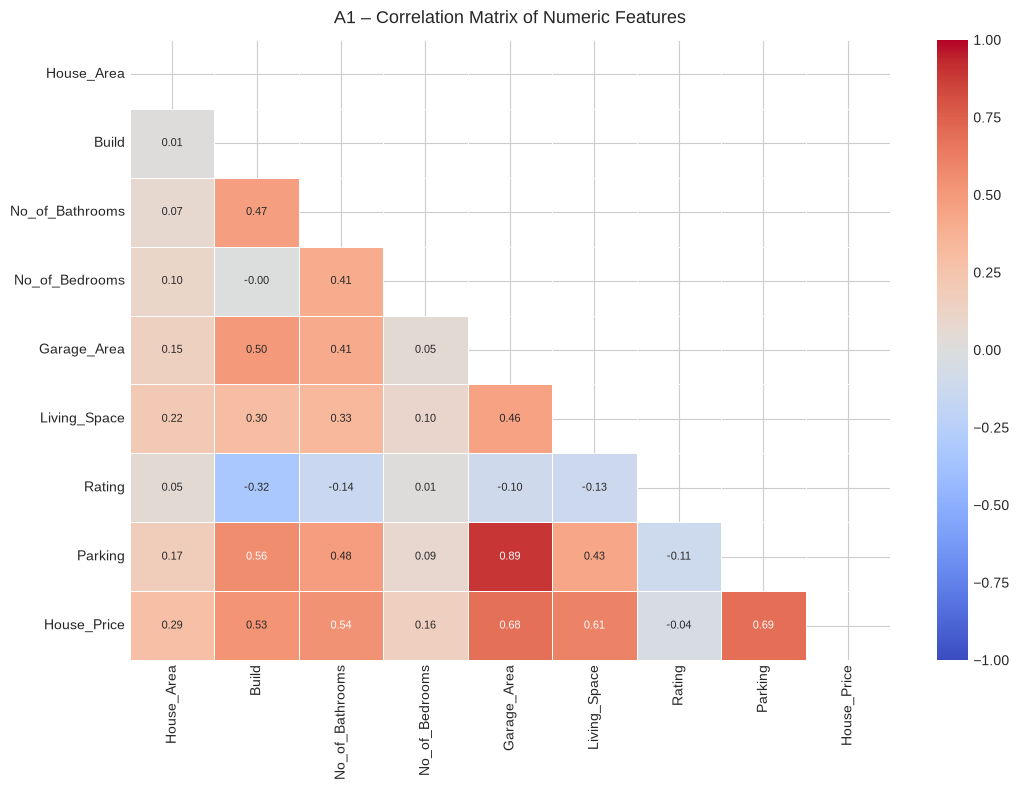

In [9]:
# A1.4 – Correlation heatmap
num_cols = df_raw_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {num_cols}")
corr = df_raw_clean[num_cols].corr()
plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8})
plt.title('A1 – Correlation Matrix of Numeric Features', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('A1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### A2 – Data Cleaning
Addresses duplicates, numeric type conversion, missing value imputation,
outlier removal (IQR), and illogical values.


In [10]:
# A2.1 – Start from cleaned numeric copy; remove duplicates
df = df_raw_clean.copy()
n_before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {n_before - len(df)} (before: {n_before}, after: {len(df)})")


Duplicates removed: 4 (before: 350, after: 346)


In [11]:
# A2.2 – Impute missing values with column median
print("Missing before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f"  '{col}' -> filled with median = {med:.2f}")
print(f"\nMissing after imputation: {df.isnull().sum().sum()}")


Missing before imputation:
No_of_Bathrooms    2
No_of_Bedrooms     2
Garage_Area        3
Living_Space       5
dtype: int64
  'No_of_Bathrooms' -> filled with median = 2.00
  'No_of_Bedrooms' -> filled with median = 3.00
  'Garage_Area' -> filled with median = 463.00
  'Living_Space' -> filled with median = 1097.00

Missing after imputation: 0


=== Outlier audit (before removal) ===
      Column   k   Lower  Upper  Outliers  % rows
 House_Price 1.5     688 343188        14     4.0
 House_Price 3.0 -127750 471625         2     0.6
  House_Area 1.5    1603  17569        17     4.9
  House_Area 3.0   -4384  23556         6     1.7
Living_Space 1.5     173   2075         5     1.4
Living_Space 3.0    -540   2788         0     0.0
 Garage_Area 1.5     -63    959         3     0.9
 Garage_Area 3.0    -446   1342         0     0.0

House_Price: removing 14 rows outside 688 - 343,188 (k=1.5)
House_Area: removing 5 extreme rows outside -3,656 - 22,444 (k=3.0)


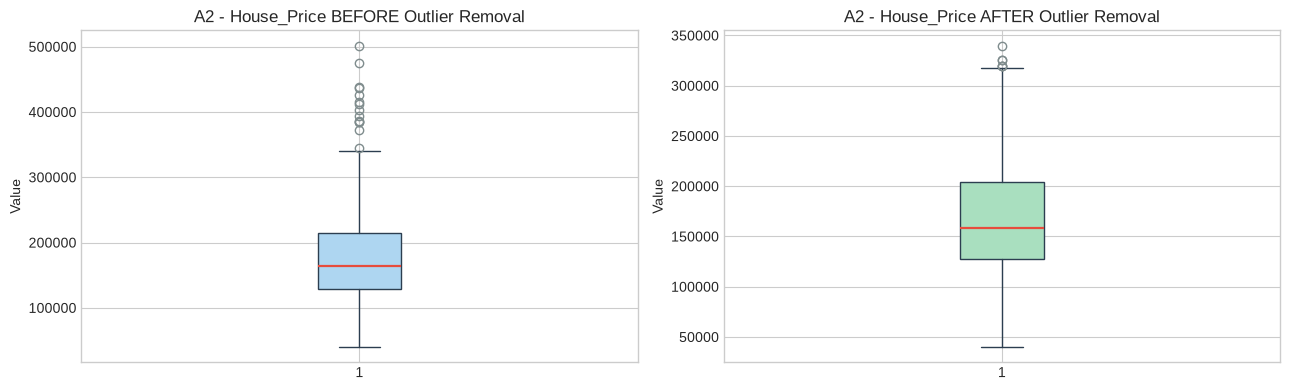


Rows: 346 -> 327 (19 removed, 5.5%)


In [12]:
# A2.3 - Outlier detection and removal (IQR rule)
# Price uses the standard 1.5*IQR fence. The area columns are naturally
# right-skewed (a few genuinely large plots), so a 3*IQR fence is used there:
# it removes only impossible values without discarding valid large properties.
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q1 - k * (q3 - q1), q3 + k * (q3 - q1)

cont_cols = [c for c in [target_col, land_col, living_col, garage_col]
             if c and c in df.columns]

audit = []
for c in cont_cols:
    for k in (1.5, 3.0):
        lo, hi = iqr_bounds(df[c], k)
        m = (df[c] < lo) | (df[c] > hi)
        audit.append({'Column': c, 'k': k, 'Lower': round(lo), 'Upper': round(hi),
                      'Outliers': int(m.sum()), '% rows': round(m.mean() * 100, 1)})
print("=== Outlier audit (before removal) ===")
print(pd.DataFrame(audit).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].boxplot(df[target_col].dropna(), patch_artist=True,
                boxprops={'facecolor': '#aed6f1', 'edgecolor': '#2c3e50'})
axes[0].set_title(f'A2 - {target_col} BEFORE Outlier Removal')
axes[0].set_ylabel('Value')

n_start = len(df)
lo, hi = iqr_bounds(df[target_col], 1.5)
price_out = (df[target_col] < lo) | (df[target_col] > hi)
print(f"\n{target_col}: removing {price_out.sum()} rows outside {lo:,.0f} - {hi:,.0f} (k=1.5)")
df = df[~price_out]

for c in [land_col, living_col, garage_col]:
    if c and c in df.columns:
        lo, hi = iqr_bounds(df[c], 3.0)
        m = (df[c] < lo) | (df[c] > hi)
        if m.sum():
            print(f"{c}: removing {m.sum()} extreme rows outside {lo:,.0f} - {hi:,.0f} (k=3.0)")
            df = df[~m]

for c in [living_col, land_col, garage_col, target_col]:
    if c and c in df.columns:
        bad = (df[c] < 0).sum()
        if bad:
            print(f"{c}: removing {bad} rows with impossible negative values")
            df = df[df[c] >= 0]

axes[1].boxplot(df[target_col].dropna(), patch_artist=True,
                boxprops={'facecolor': '#a9dfbf', 'edgecolor': '#2c3e50'})
axes[1].set_title(f'A2 - {target_col} AFTER Outlier Removal')
axes[1].set_ylabel('Value')
plt.tight_layout()
plt.savefig('A2_outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nRows: {n_start} -> {len(df)} ({n_start - len(df)} removed, "
      f"{(n_start - len(df)) / n_start * 100:.1f}%)")


In [13]:
# A2.4 – Cleaned dataset summary
df.describe().round(2)


,House_Area,Build,No_of_Bathrooms,No_of_Bedrooms,Garage_Area,Living_Space,Rating,Parking,House_Price
count,327.00,327.00,327.00,327.00,327.00,327.00,327.00,327.00,327.00
mean,9431.79,1970.86,1.54,2.84,446.18,1125.20,5.54,1.66,170002.72
std,3449.77,29.58,0.55,0.77,199.56,331.35,1.11,0.73,59543.63
min,1596.00,1880.00,0.00,0.00,0.00,483.00,2.00,0.00,40000.00
25%,7486.00,1953.00,1.00,2.00,312.00,882.00,5.00,1.00,127750.00
50%,9180.00,1972.00,2.00,3.00,454.00,1085.00,5.00,2.00,158000.00
75%,11171.50,1999.50,2.00,3.00,572.00,1319.00,6.00,2.00,204375.00
max,21453.00,2009.00,3.00,6.00,1053.00,2259.00,9.00,3.00,340000.00


### A3 – Data Visualisation
Charts reveal distribution shapes, inter-feature relationships, and how features
relate to the target price variable.


Valid price values: 327
Range: 40,000 to 340,000


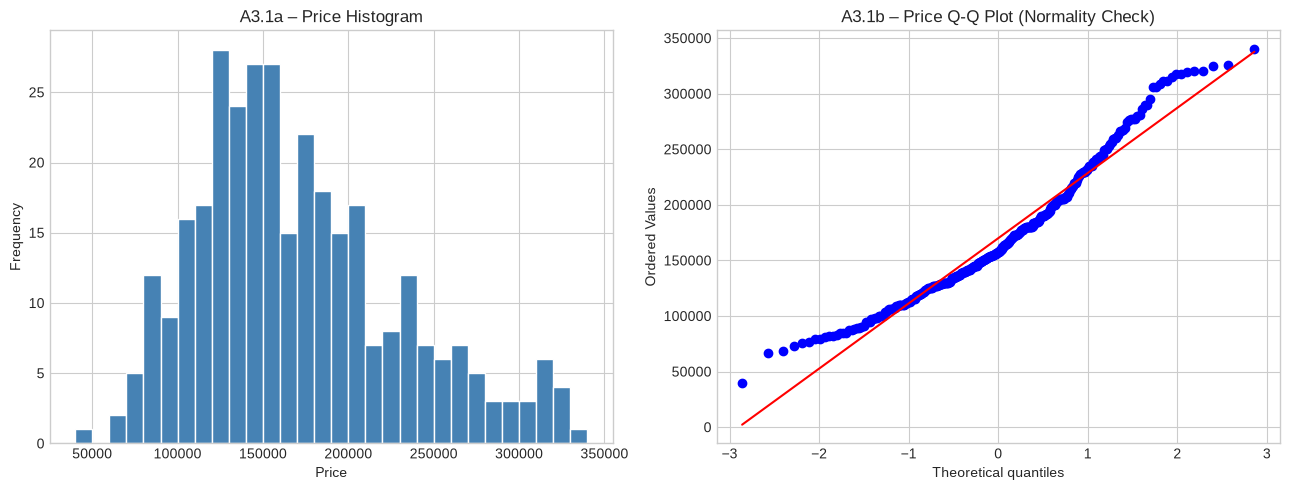

Price skewness: 0.707  (|skew| > 1 suggests right-skew)


In [14]:
# A3.1 – Price histogram and Q-Q plot
# Justification: Price is the regression target. Skewness assessment guides
# whether log-transformation is needed before modelling.
price_data = df[target_col].dropna()
print(f"Valid price values: {len(price_data)}")
print(f"Range: {price_data.min():,.0f} to {price_data.max():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(price_data, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('A3.1a – Price Histogram')
axes[0].set_xlabel('Price'); axes[0].set_ylabel('Frequency')
stats.probplot(price_data, plot=axes[1])
axes[1].set_title('A3.1b – Price Q-Q Plot (Normality Check)')
plt.tight_layout()
plt.savefig('A3_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Price skewness: {price_data.skew():.3f}  (|skew| > 1 suggests right-skew)")


Discrete (count) features : ['No_of_Bathrooms', 'No_of_Bedrooms', 'Rating', 'Parking']
Continuous features       : ['House_Area', 'Build', 'Garage_Area', 'Living_Space']


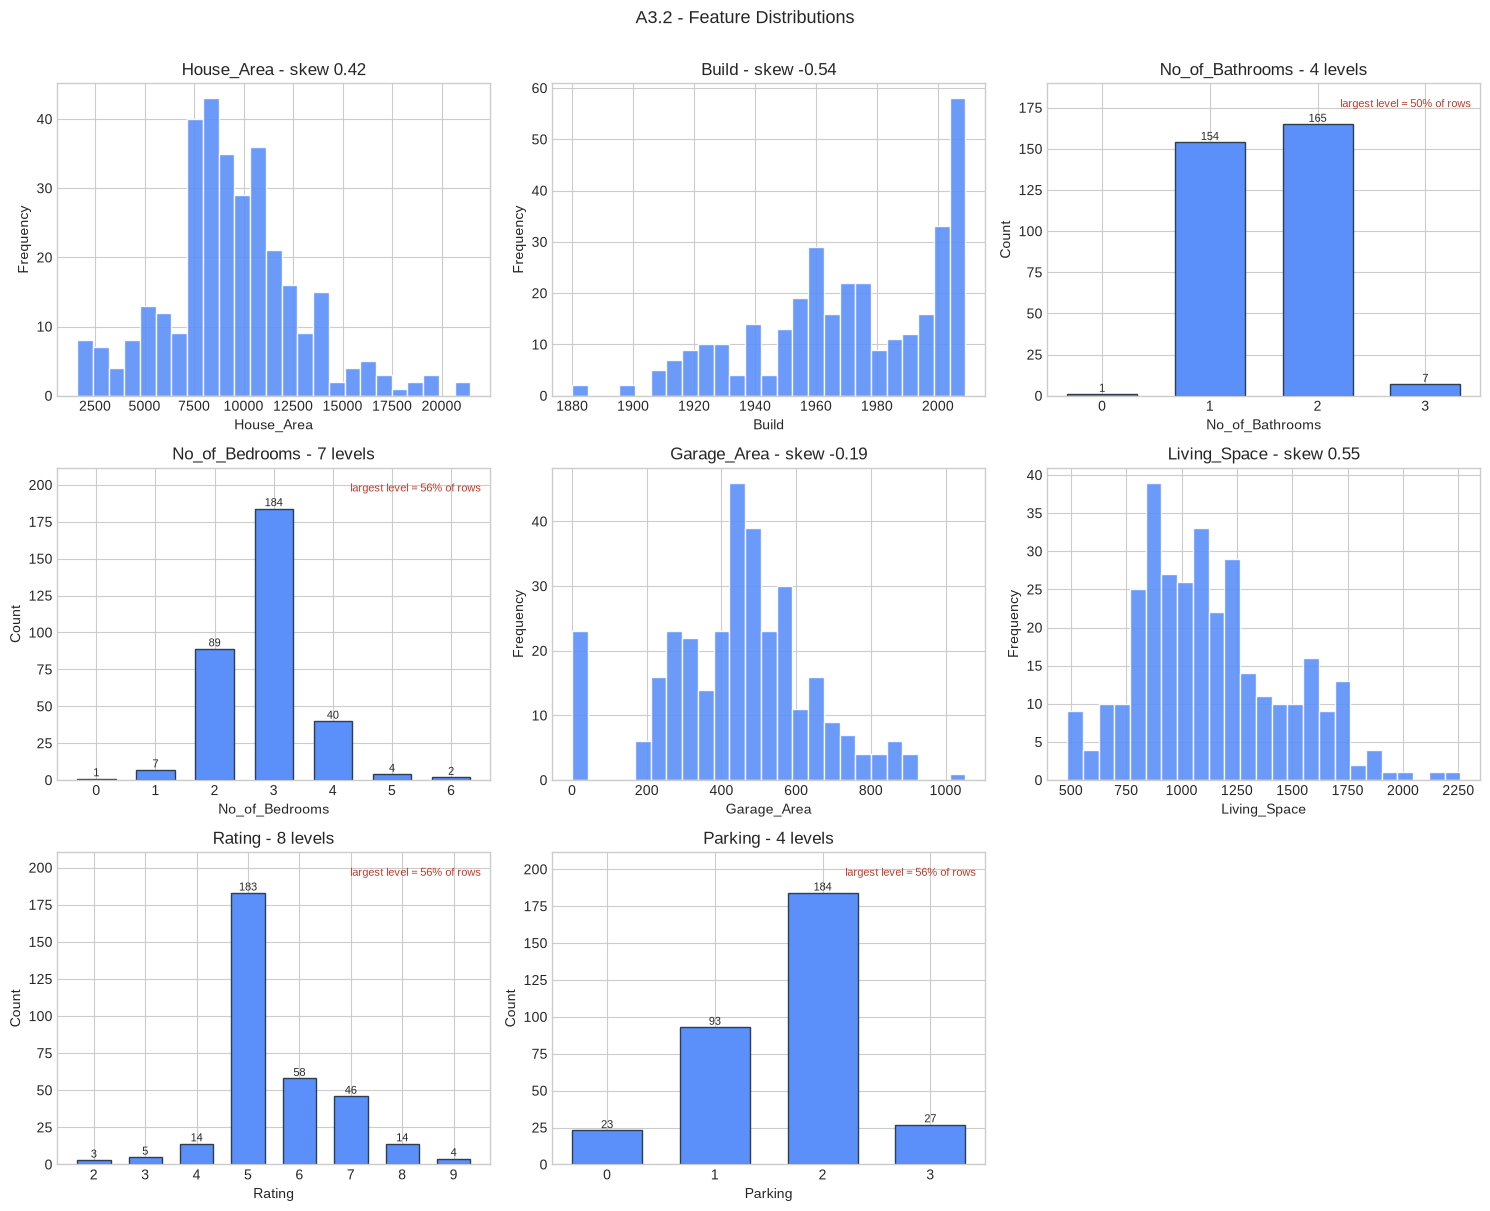

In [15]:
# A3.2 - Feature distributions
# Justification: distribution shape drives preprocessing choices. Count features
# (bedrooms, bathrooms, rating, parking) take only a handful of whole-number
# values, so a histogram invents meaningless fractional bins and hides class
# imbalance - those are drawn as category bars instead. Continuous features keep
# histograms, annotated with skewness.
num_feats = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]

def is_discrete(s, max_levels=12):
    v = s.dropna()
    return v.nunique() <= max_levels and np.allclose(v, v.round())

discrete   = [c for c in num_feats if is_discrete(df[c])]
continuous = [c for c in num_feats if c not in discrete]
print(f"Discrete (count) features : {discrete}")
print(f"Continuous features       : {continuous}")

n_cols = 3
n_rows = max(1, (len(num_feats) + n_cols - 1) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(num_feats):
    ax = axes[i]
    if col in discrete:
        counts = df[col].dropna().astype(int).value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values,
               color='#5b8ff9', edgecolor='#2c3e50', width=0.65)
        for xi, yi in zip(range(len(counts)), counts.values):
            ax.text(xi, yi, str(yi), ha='center', va='bottom', fontsize=8)
        share = counts.max() / counts.sum()
        ax.set_title(f'{col} - {len(counts)} levels')
        ax.set_ylabel('Count')
        ax.text(0.98, 0.95, f'largest level = {share:.0%} of rows',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color='#c0392b')
        ax.margins(y=0.15)
    else:
        data = df[col].dropna()
        ax.hist(data, bins=25, color='#5b8ff9', edgecolor='white', alpha=0.9)
        ax.set_title(f'{col} - skew {data.skew():.2f}')
        ax.set_ylabel('Frequency')
    ax.set_xlabel(col)

for j in range(len(num_feats), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('A3.2 - Feature Distributions', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('A3_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


Top 2 features correlated with House_Price: ['Parking', 'Garage_Area']


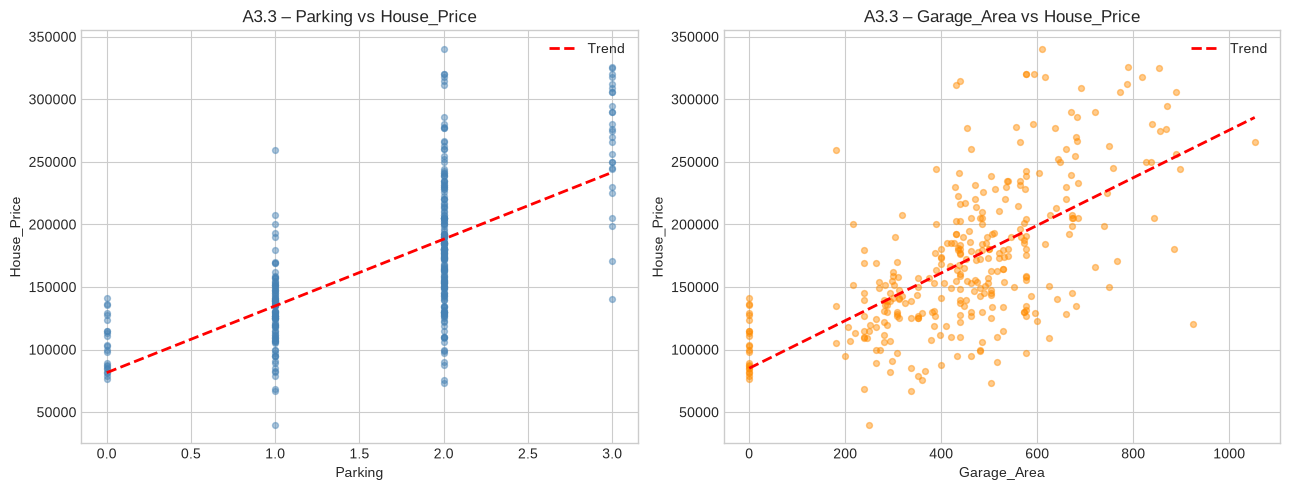

In [16]:
# A3.3 – Scatter plots: Price vs top two correlated features
# Justification: Reveals linear/non-linear relationships between predictors and price.
corr_price = df.corr()[target_col].abs().drop(target_col).sort_values(ascending=False)
top2 = corr_price.index[:2].tolist()
print(f"Top 2 features correlated with {target_col}: {top2}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat, col in zip(axes, top2, ['steelblue', 'darkorange']):
    data = df[[feat, target_col]].dropna()
    ax.scatter(data[feat], data[target_col], alpha=0.45, s=18, color=col)
    m, b = np.polyfit(data[feat], data[target_col], 1)
    xr = np.linspace(data[feat].min(), data[feat].max(), 100)
    ax.plot(xr, m*xr + b, 'r--', lw=2, label='Trend')
    ax.set_title(f'A3.3 – {feat} vs {target_col}')
    ax.set_xlabel(feat); ax.set_ylabel(target_col)
    ax.legend()
plt.tight_layout()
plt.savefig('A3_scatter_price.png', dpi=150, bbox_inches='tight')
plt.show()


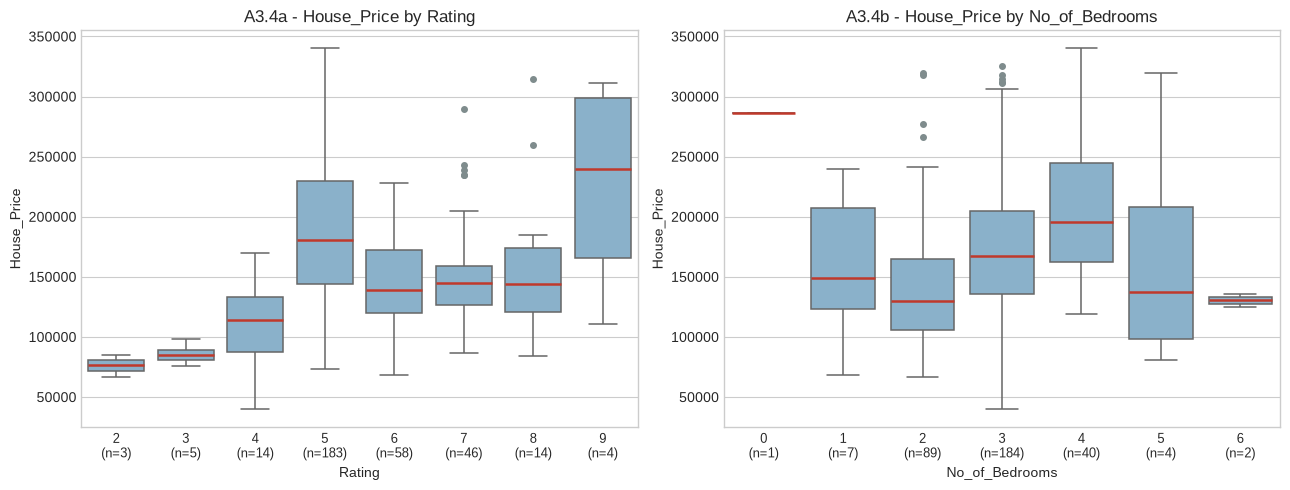

In [17]:
# A3.4 - Box plots: Price by Rating and Bedrooms
# Justification: compares price distributions across categorical groups,
# revealing which property grades and sizes command premium prices. Boxes are
# filled so the interquartile range stays readable on the white grid style.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

box_kw = dict(
    color='#7fb3d5',
    linewidth=1.1,
    medianprops={'color': '#c0392b', 'linewidth': 1.8},
    flierprops={'marker': 'o', 'markersize': 4,
                'markerfacecolor': '#7f8c8d', 'markeredgecolor': '#7f8c8d'},
)

for ax, cat_col, tag in [(axes[0], rating_col, 'A3.4a'), (axes[1], beds_col, 'A3.4b')]:
    if cat_col and cat_col in df.columns:
        pdata = df[[target_col, cat_col]].dropna().copy()
        pdata[cat_col] = pdata[cat_col].astype(int)
        sns.boxplot(data=pdata, x=cat_col, y=target_col, ax=ax, **box_kw)
        counts = pdata[cat_col].value_counts().sort_index()
        ax.set_xticklabels([f'{v}\n(n={counts[v]})' for v in counts.index], fontsize=9)
        ax.set_title(f'{tag} - {target_col} by {cat_col}')
        ax.set_xlabel(cat_col); ax.set_ylabel(target_col)
    else:
        ax.text(0.5, 0.5, 'Column not found', ha='center', va='center')

plt.tight_layout()
plt.savefig('A3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


Pair plot features: ['Parking', 'Garage_Area', 'No_of_Bathrooms', 'Build', 'House_Price']


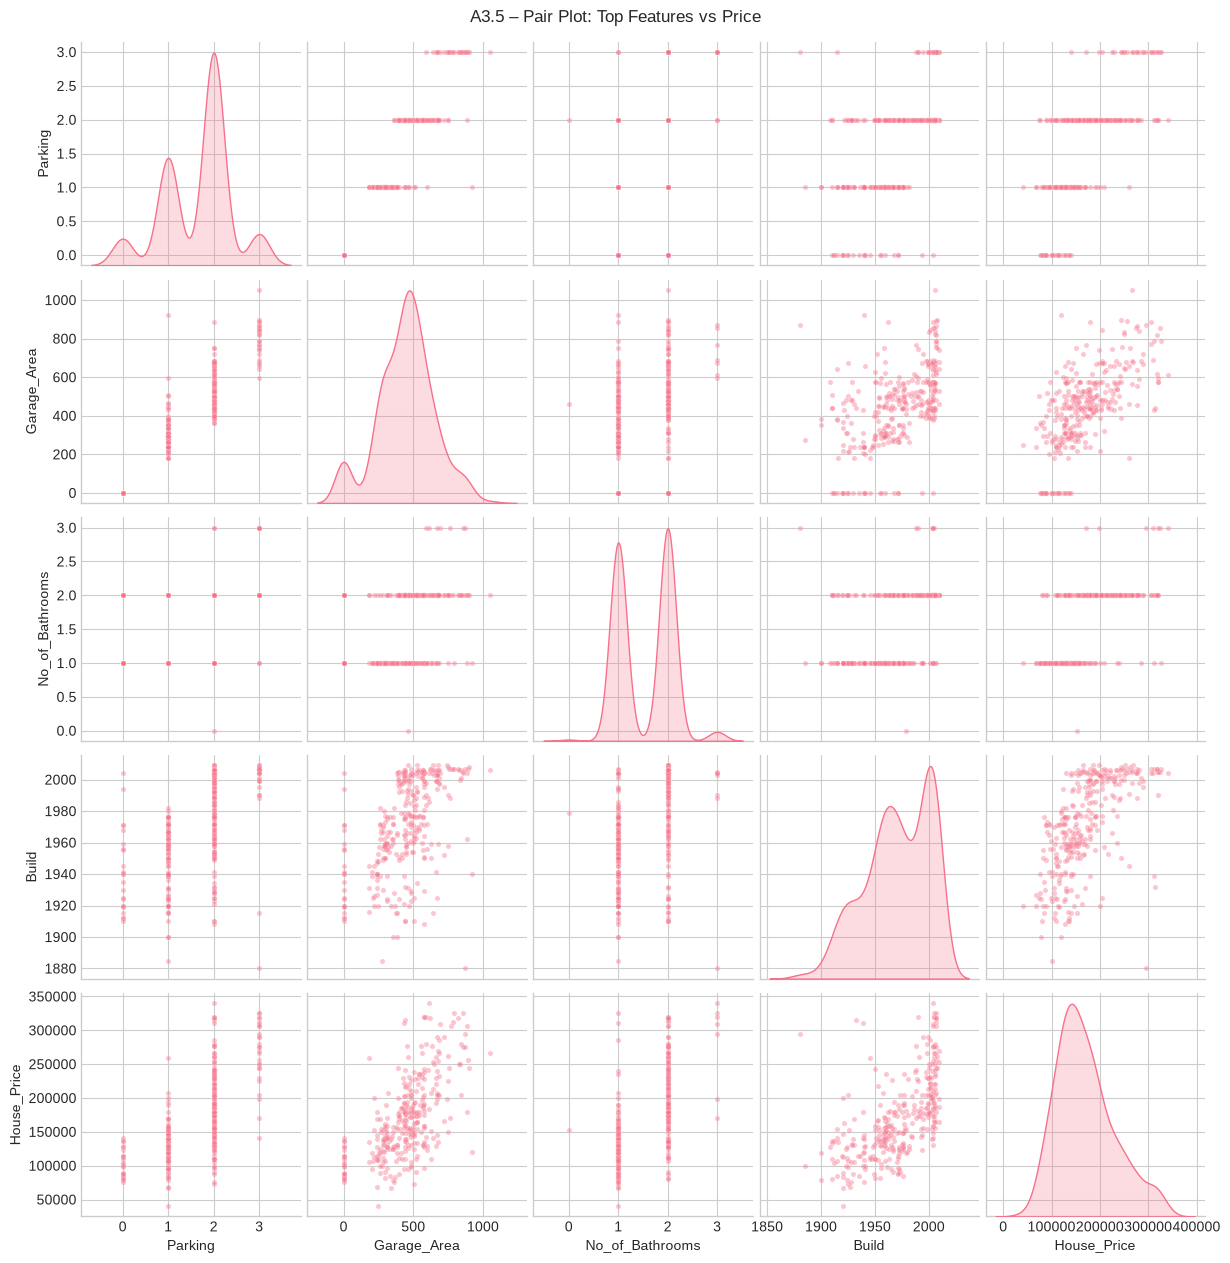

In [18]:
# A3.5 – Pair plot of top correlated features
# Justification: Shows pairwise relationships in one view, helping identify
# multicollinearity and feature interactions simultaneously.
top_feats = corr_price.index[:4].tolist() + [target_col]
print("Pair plot features:", top_feats)
g = sns.pairplot(df[top_feats].dropna(), diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 14})
g.fig.suptitle('A3.5 – Pair Plot: Top Features vs Price', y=1.01, fontsize=12)
plt.savefig('A3_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


=== Rating class balance ===
        Count  Share %
Rating                
2           3      0.9
3           5      1.5
4          14      4.3
5         183     56.0
6          58     17.7
7          46     14.1
8          14      4.3
9           4      1.2

Majority class : 5 (56.0% of rows)
Imbalance ratio: 61.0 : 1
Classes with fewer than 10 samples: [2, 3, 9] - these cannot be learned reliably and drag down macro-averaged scores.


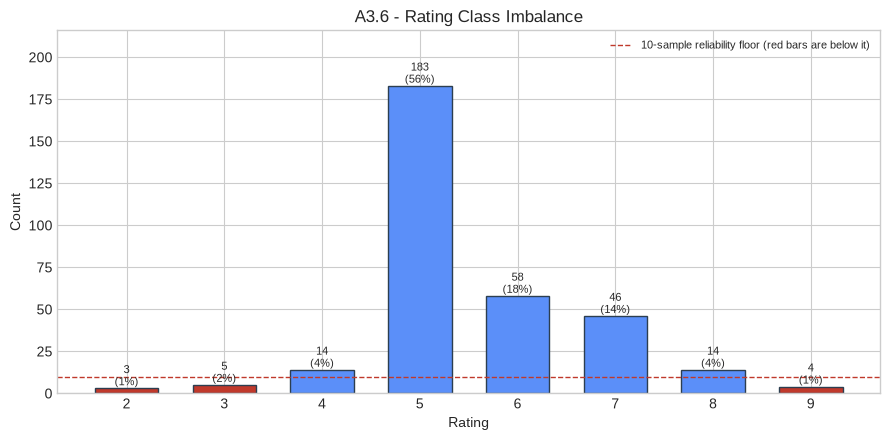

In [19]:
# A3.6 - Class balance of the classification target (Rating)
# Justification: Sections B2/B3 classify Rating. If one grade dominates, a model
# can score high accuracy by always predicting it, so the imbalance must be
# measured here and carried into the choice of metric and class weighting.
rating_counts = df[rating_col].dropna().astype(int).value_counts().sort_index()
share = rating_counts / rating_counts.sum()

print("=== Rating class balance ===")
print(pd.DataFrame({'Count': rating_counts, 'Share %': (share * 100).round(1)}).to_string())
print(f"\nMajority class : {rating_counts.idxmax()} "
      f"({share.max() * 100:.1f}% of rows)")
print(f"Imbalance ratio: {rating_counts.max() / rating_counts.min():.1f} : 1")
rare = rating_counts[rating_counts < 10]
if len(rare):
    print(f"Classes with fewer than 10 samples: {rare.index.tolist()} "
          "- these cannot be learned reliably and drag down macro-averaged scores.")

plt.figure(figsize=(9, 4.5))
colours = ['#c0392b' if c < 10 else '#5b8ff9' for c in rating_counts.values]
plt.bar(rating_counts.index.astype(str), rating_counts.values,
        color=colours, edgecolor='#2c3e50', width=0.65)
for xi, yi in zip(range(len(rating_counts)), rating_counts.values):
    plt.text(xi, yi, f'{yi}\n({yi / rating_counts.sum() * 100:.0f}%)',
             ha='center', va='bottom', fontsize=8)
plt.axhline(10, color='#c0392b', ls='--', lw=1,
            label='10-sample reliability floor (red bars are below it)')
plt.xlabel(rating_col); plt.ylabel('Count')
plt.title('A3.6 - Rating Class Imbalance')
plt.legend(fontsize=8); plt.margins(y=0.18)
plt.tight_layout()
plt.savefig('A3_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section B: AI/ML – Scenario 1
**[30% of total marks]**


### ML Feature Preparation

In [20]:
# Prepare regression and classification datasets
X_reg_df = df[feature_cols].copy()
y_reg     = df[target_col].copy()
mask_r    = X_reg_df.notna().all(axis=1) & y_reg.notna()
X_reg_df, y_reg = X_reg_df[mask_r], y_reg[mask_r]

X_cls_df  = df[feature_cols].copy()
y_cls     = df[rating_col].astype(float).round().astype(int).copy()
mask_c    = X_cls_df.notna().all(axis=1) & y_cls.notna()
X_cls_df, y_cls = X_cls_df[mask_c], y_cls[mask_c]

scaler_r = StandardScaler()
scaler_c = StandardScaler()
X_reg_s  = scaler_r.fit_transform(X_reg_df)
X_cls_s  = scaler_c.fit_transform(X_cls_df)

print(f"Regression:     X={X_reg_s.shape}, y={y_reg.shape}")
print(f"Classification: X={X_cls_s.shape}, y={y_cls.shape}")
print(f"Rating classes: {sorted(y_cls.unique())}")


Regression:     X=(327, 7), y=(327,)
Classification: X=(327, 7), y=(327,)
Rating classes: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


### B1 – Multiple Linear Regression
Three train/test splits are evaluated. Metrics: MAE, RMSE, R².
A sample price prediction is shown using the best model.


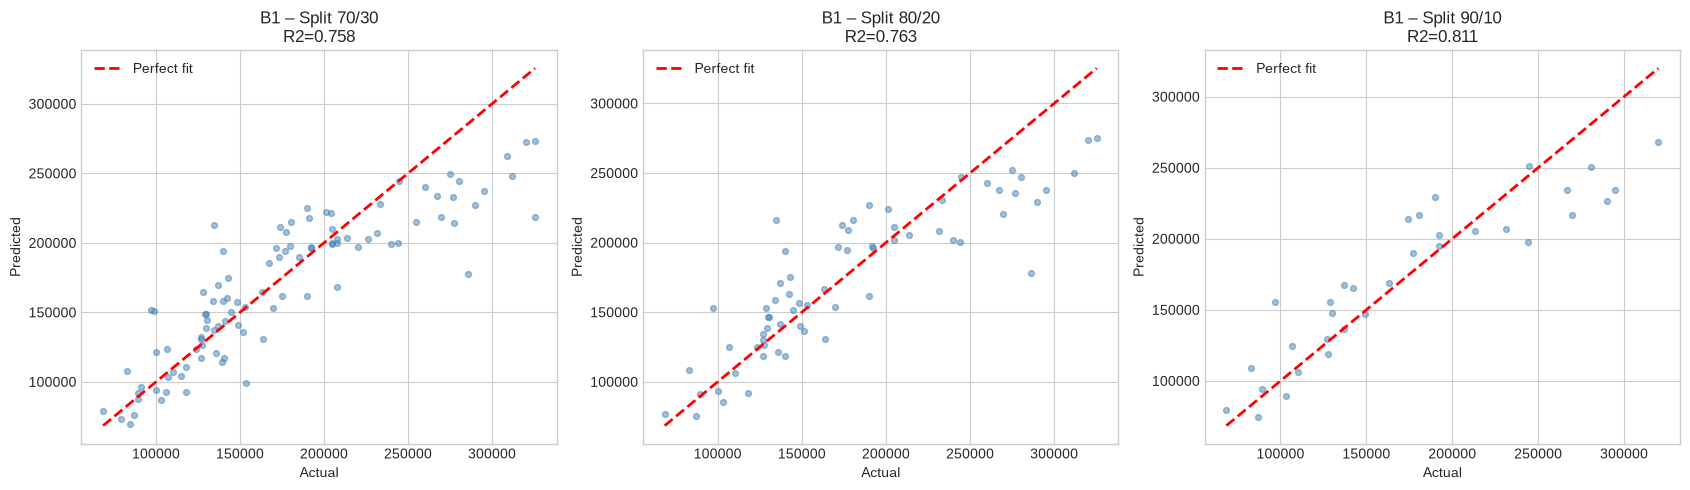

=== B1: Linear Regression Metrics ===
Split  Train  Test      MAE     RMSE   R2
70/30    228    99 23702.69 31972.23 0.76
80/20    261    66 24111.50 31917.46 0.76
90/10    294    33 23772.38 30314.87 0.81


In [21]:
splits = [('70/30', 0.30), ('80/20', 0.20), ('90/10', 0.10)]
lr_results = []

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, (label, ts) in enumerate(splits):
    X_tr, X_te, y_tr, y_te = train_test_split(X_reg_s, y_reg, test_size=ts, random_state=42)
    mdl = LinearRegression().fit(X_tr, y_tr)
    y_hat = mdl.predict(X_te)
    mae  = mean_absolute_error(y_te, y_hat)
    rmse = np.sqrt(mean_squared_error(y_te, y_hat))
    r2   = r2_score(y_te, y_hat)
    lr_results.append({'Split': label, 'Train': len(y_tr), 'Test': len(y_te),
                        'MAE': mae, 'RMSE': rmse, 'R2': r2,
                        '_model': mdl, '_y_te': y_te, '_y_hat': y_hat})
    axes[i].scatter(y_te, y_hat, alpha=0.5, s=18, color='steelblue')
    mn, mx = min(y_te.min(), y_hat.min()), max(y_te.max(), y_hat.max())
    axes[i].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect fit')
    axes[i].set_title(f'B1 – Split {label}\nR2={r2:.3f}')
    axes[i].set_xlabel('Actual'); axes[i].set_ylabel('Predicted')
    axes[i].legend()
plt.tight_layout()
plt.savefig('B1_regression.png', dpi=150, bbox_inches='tight')
plt.show()

summary_lr = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                            for r in lr_results])
print("=== B1: Linear Regression Metrics ===")
print(summary_lr.round(2).to_string(index=False))


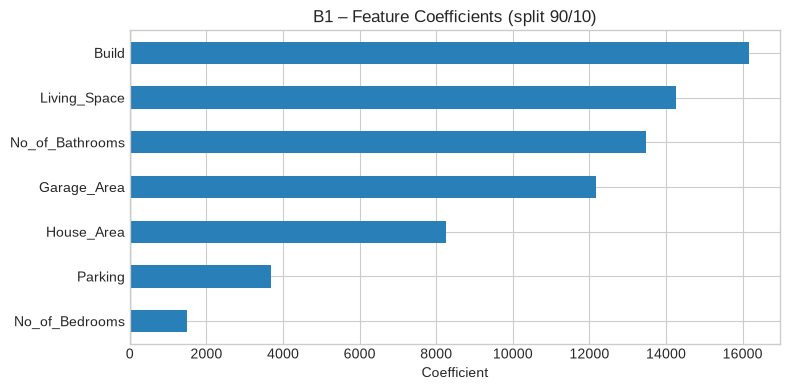

In [22]:
# B1 – Feature coefficients (best split)
best_idx = summary_lr['R2'].idxmax()
best_lr  = lr_results[best_idx]
coef_ser = pd.Series(best_lr['_model'].coef_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 4))
colours = ['#e74c3c' if c < 0 else '#2980b9' for c in coef_ser]
coef_ser.plot(kind='barh', color=colours)
plt.axvline(0, color='black', lw=0.8)
plt.title(f"B1 – Feature Coefficients (split {best_lr['Split']})")
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('B1_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
# B1 – Price prediction for a sample property
sample = {col: float(df[col].median()) for col in feature_cols}
sample_s = scaler_r.transform(pd.DataFrame([sample]))
predicted = best_lr['_model'].predict(sample_s)[0]
print("=== Price Prediction Example (median property) ===")
for k, v in sample.items():
    print(f"  {k:20s}: {v:.1f}")
print(f"\n  Predicted {target_col}: {predicted:,.0f}")


=== Price Prediction Example (median property) ===
  House_Area          : 9180.0
  Build               : 1972.0
  No_of_Bathrooms     : 2.0
  No_of_Bedrooms      : 3.0
  Garage_Area         : 454.0
  Living_Space        : 1085.0
  Parking             : 2.0

  Predicted House_Price: 181,951


### B2 - k-Nearest Neighbours Classification for Rating
`k` is selected by 5-fold **cross-validation on the training set only**. Selecting `k`
by test-set accuracy would leak the test data into model selection and inflate the
reported score. Because Rating is heavily imbalanced (Section A3.6), macro-averaged
F1 and balanced accuracy are reported alongside plain accuracy: a model that always
predicts grade 5 already scores ~56% accuracy while learning nothing.


Smallest training class: 2 samples -> using 2-fold CV


Best k by CV macro-F1 = 11 (CV macro-F1 = 0.1511)
For contrast, k that maximises TEST accuracy = 7 - chosen only for illustration, using it would leak the test set.


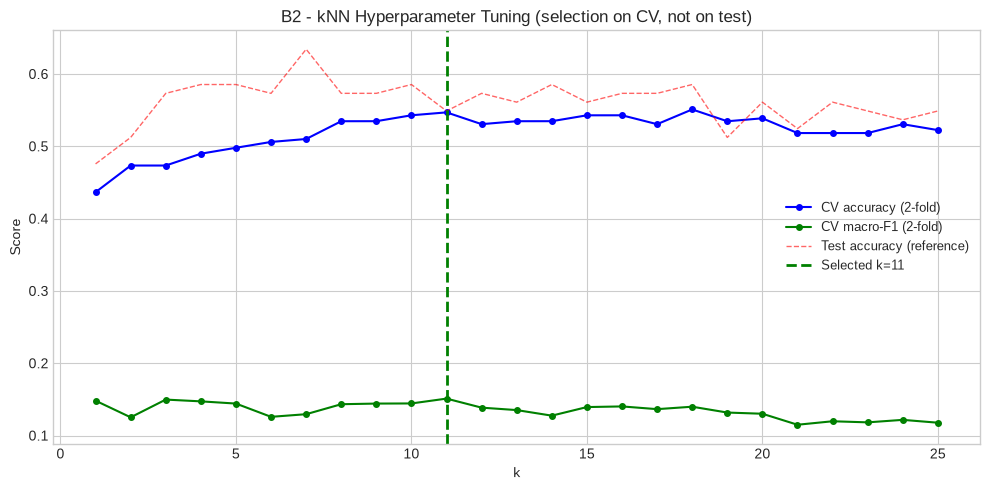


Analysis of k: very small k (1-3) overfits - each prediction follows a single noisy neighbour. Large k over-smooths and collapses onto the majority grade, so accuracy stays flat near the 56% majority-class baseline while macro-F1 falls. The selected k balances the two.


In [24]:
# B2.1 - Hyperparameter tuning for k by cross-validation (no test-set leakage)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls_s, y_cls, test_size=0.25, random_state=42, stratify=y_cls)

# Rare grades have too few members for 5 folds, so the fold count is capped by
# the smallest class size in the training split.
min_class = y_tr.value_counts().min()
n_folds   = int(max(2, min(5, min_class)))
cv        = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
print(f"Smallest training class: {min_class} samples -> using {n_folds}-fold CV")

k_range = range(1, 26)
cv_macro_f1, cv_acc, test_accs = [], [], []
for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k)
    cv_macro_f1.append(cross_val_score(m, X_tr, y_tr, cv=cv,
                                       scoring='f1_macro').mean())
    cv_acc.append(cross_val_score(m, X_tr, y_tr, cv=cv,
                                  scoring='accuracy').mean())
    test_accs.append(m.fit(X_tr, y_tr).score(X_te, y_te))   # shown for comparison only

best_k = list(k_range)[int(np.argmax(cv_macro_f1))]
print(f"Best k by CV macro-F1 = {best_k} (CV macro-F1 = {max(cv_macro_f1):.4f})")
print(f"For contrast, k that maximises TEST accuracy = "
      f"{list(k_range)[int(np.argmax(test_accs))]} - chosen only for illustration, "
      "using it would leak the test set.")

plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_acc,      'b-o', ms=4, label=f'CV accuracy ({n_folds}-fold)')
plt.plot(k_range, cv_macro_f1, 'g-o', ms=4, label=f'CV macro-F1 ({n_folds}-fold)')
plt.plot(k_range, test_accs,   'r--', lw=1, alpha=0.6, label='Test accuracy (reference)')
plt.axvline(best_k, color='green', lw=2, ls='--', label=f'Selected k={best_k}')
plt.xlabel('k'); plt.ylabel('Score')
plt.title('B2 - kNN Hyperparameter Tuning (selection on CV, not on test)')
plt.legend(fontsize=9); plt.tight_layout()
plt.savefig('B2_knn_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAnalysis of k: very small k (1-3) overfits - each prediction follows a single "
      "noisy neighbour. Large k over-smooths and collapses onto the majority grade, so "
      "accuracy stays flat near the 56% majority-class baseline while macro-F1 falls. "
      "The selected k balances the two.")


=== kNN Evaluation (k=11) ===
Majority-class baseline : 0.5610   <- any model must beat this
Accuracy                : 0.5488
Balanced accuracy       : 0.1545
Precision (weighted)    : 0.4769
Recall (weighted)       : 0.5488
F1 (weighted)           : 0.4906
F1 (macro)              : 0.1502   <- treats every grade equally

=== Classification Report ===
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3
           5       0.63      0.87      0.73        46
           6       0.50      0.20      0.29        15
           7       0.20      0.17      0.18        12
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         1

    accuracy                           0.55        82
   macro avg       0.17      0.15      0.15        82
weighted avg       0.48      0.55      0.49       

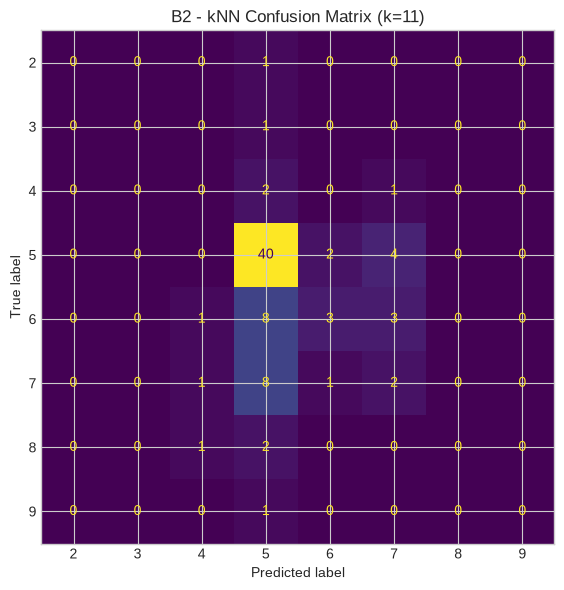

In [25]:
# B2.2 - Evaluate the tuned kNN model
baseline = y_te.value_counts(normalize=True).max()

knn_best  = KNeighborsClassifier(n_neighbors=best_k).fit(X_tr, y_tr)
y_hat_knn = knn_best.predict(X_te)
knn_acc   = accuracy_score(y_te, y_hat_knn)
knn_bacc  = balanced_accuracy_score(y_te, y_hat_knn)
knn_f1    = f1_score(y_te, y_hat_knn, average='weighted', zero_division=0)
knn_mf1   = f1_score(y_te, y_hat_knn, average='macro',    zero_division=0)

print(f"=== kNN Evaluation (k={best_k}) ===")
print(f"Majority-class baseline : {baseline:.4f}   <- any model must beat this")
print(f"Accuracy                : {knn_acc:.4f}")
print(f"Balanced accuracy       : {knn_bacc:.4f}")
print(f"Precision (weighted)    : {precision_score(y_te, y_hat_knn, average='weighted', zero_division=0):.4f}")
print(f"Recall (weighted)       : {recall_score(y_te, y_hat_knn, average='weighted', zero_division=0):.4f}")
print(f"F1 (weighted)           : {knn_f1:.4f}")
print(f"F1 (macro)              : {knn_mf1:.4f}   <- treats every grade equally")
print("\n=== Classification Report ===")
print(classification_report(y_te, y_hat_knn, zero_division=0))
print("Metric meanings: precision = of the properties predicted as a grade, how many "
      "really are; recall = of the properties truly of that grade, how many were found; "
      "F1 = their harmonic mean. Weighted averaging is dominated by grade 5, so the gap "
      "between weighted and macro F1 measures how badly the minority grades are served.")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_te, y_hat_knn, ax=ax, colorbar=False)
ax.set_title(f'B2 - kNN Confusion Matrix (k={best_k})')
plt.tight_layout()
plt.savefig('B2_knn_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


### B3 - Support Vector Machine Classification
Three kernels are compared, each tuned over `C` (and `gamma` for RBF) by
cross-validation. `class_weight='balanced'` is applied so the rare grades are not
ignored in favour of the dominant grade 5. The comparison against kNN uses the same
train/test split and the same metrics.


In [26]:
# B3.1 - SVM with per-kernel hyperparameter tuning and class balancing
param_grids = {
    'Linear':  {'C': [0.1, 1, 10, 100]},
    'RBF':     {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1, 1]},
    'Poly(3)': {'C': [0.1, 1, 10], 'gamma': ['scale', 0.1]},
}
base = {
    'Linear':  SVC(kernel='linear', class_weight='balanced', random_state=42),
    'RBF':     SVC(kernel='rbf',    class_weight='balanced', random_state=42),
    'Poly(3)': SVC(kernel='poly', degree=3, class_weight='balanced', random_state=42),
}

svm_res = {}
best_svm_name, best_svm_score, best_svm_pred, best_svm_params = None, -1, None, None
for name, mdl in base.items():
    gs = GridSearchCV(mdl, param_grids[name], cv=cv, scoring='f1_macro', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    pred = gs.best_estimator_.predict(X_te)
    acc  = accuracy_score(y_te, pred)
    svm_res[name] = {
        'Best params':   str(gs.best_params_),
        'CV macro-F1':   round(gs.best_score_, 4),
        'Accuracy':      round(acc, 4),
        'Balanced acc':  round(balanced_accuracy_score(y_te, pred), 4),
        'F1 (weighted)': round(f1_score(y_te, pred, average='weighted', zero_division=0), 4),
        'F1 (macro)':    round(f1_score(y_te, pred, average='macro', zero_division=0), 4),
    }
    if gs.best_score_ > best_svm_score:
        best_svm_score, best_svm_name = gs.best_score_, name
        best_svm_pred, best_svm_params = pred, gs.best_params_

print("=== SVM Results by Kernel (tuned, class-balanced) ===")
print(pd.DataFrame(svm_res).T.to_string())
print(f"\nBest kernel by CV macro-F1: {best_svm_name} {best_svm_params}")

best_svm_acc = accuracy_score(y_te, best_svm_pred)


=== SVM Results by Kernel (tuned, class-balanced) ===
                        Best params CV macro-F1 Accuracy Balanced acc F1 (weighted) F1 (macro)
Linear                   {'C': 100}      0.1543   0.4634       0.2834        0.5026     0.2144
RBF        {'C': 100, 'gamma': 0.1}      0.1771   0.5122       0.3322        0.5421     0.3229
Poly(3)  {'C': 1, 'gamma': 'scale'}      0.1721   0.5244       0.3174        0.5117     0.2528

Best kernel by CV macro-F1: RBF {'C': 100, 'gamma': 0.1}


=== B3: kNN vs SVM ===
Majority-class baseline accuracy: 0.5610
     Model  Accuracy  Balanced acc  F1 (weighted)  F1 (macro)
kNN (k=11)    0.5488        0.1545         0.4906      0.1502
 SVM (RBF)    0.5122        0.3322         0.5421      0.3229


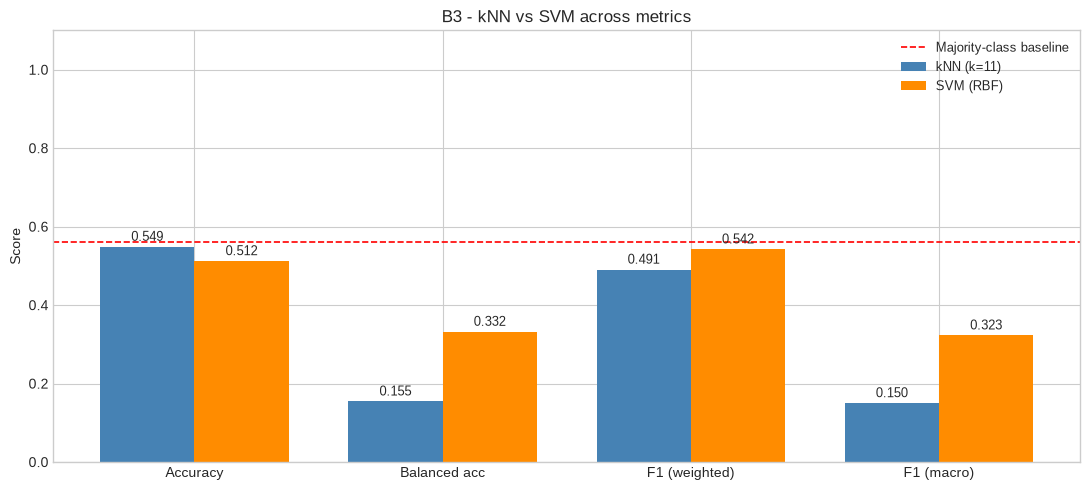

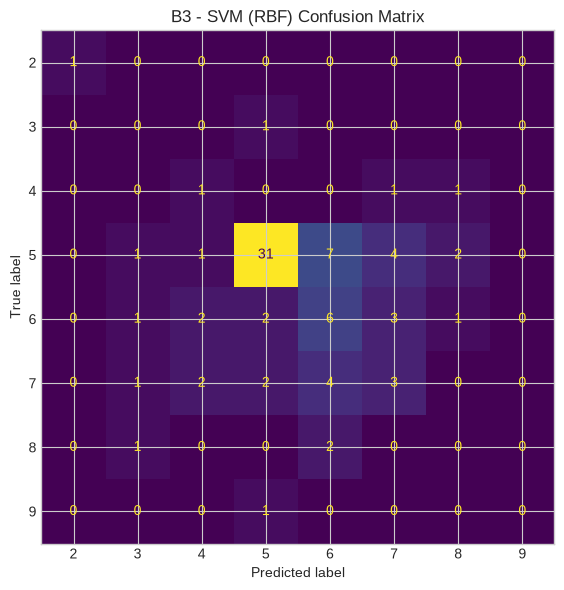


Analysis: on raw accuracy the stronger model is kNN (k=11), but on macro-F1 -
the metric that weights every grade equally - it is SVM (RBF). Class weighting
pushes the SVM to spend errors on the majority grade in order to recover minority
grades, which lowers accuracy while raising balanced accuracy. Because the estate
agent cares about identifying the unusual high and low grade properties, and not
merely about repeating the most common grade, macro-F1 and balanced accuracy are
the more honest basis for the decision. Both models sit close to the
56.1% majority-class baseline, which shows the seven structural features
carry only limited information about the subjective Rating - consistent with the
near-zero Rating/Price correlation found in Section A1.


In [27]:
# B3.2 - kNN vs SVM comparison
svm_f1   = f1_score(y_te, best_svm_pred, average='weighted', zero_division=0)
svm_mf1  = f1_score(y_te, best_svm_pred, average='macro',    zero_division=0)
svm_bacc = balanced_accuracy_score(y_te, best_svm_pred)

cmp = pd.DataFrame({
    'Model':          [f'kNN (k={best_k})', f'SVM ({best_svm_name})'],
    'Accuracy':       [knn_acc,  best_svm_acc],
    'Balanced acc':   [knn_bacc, svm_bacc],
    'F1 (weighted)':  [knn_f1,   svm_f1],
    'F1 (macro)':     [knn_mf1,  svm_mf1],
})
print("=== B3: kNN vs SVM ===")
print(f"Majority-class baseline accuracy: {baseline:.4f}")
print(cmp.round(4).to_string(index=False))

metrics = ['Accuracy', 'Balanced acc', 'F1 (weighted)', 'F1 (macro)']
x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, cmp.loc[0, metrics].values, w, label=cmp.loc[0, 'Model'], color='steelblue')
ax.bar(x + w/2, cmp.loc[1, metrics].values, w, label=cmp.loc[1, 'Model'], color='darkorange')
ax.axhline(baseline, color='red', ls='--', lw=1.2, label='Majority-class baseline')
for xi, (a, b) in enumerate(zip(cmp.loc[0, metrics].values, cmp.loc[1, metrics].values)):
    ax.text(xi - w/2, a + 0.015, f'{a:.3f}', ha='center', fontsize=9)
    ax.text(xi + w/2, b + 0.015, f'{b:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0, 1.1)
ax.set_ylabel('Score'); ax.set_title('B3 - kNN vs SVM across metrics')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('B3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_te, best_svm_pred, ax=ax2, colorbar=False)
ax2.set_title(f'B3 - SVM ({best_svm_name}) Confusion Matrix')
plt.tight_layout()
plt.savefig('B3_svm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

winner_acc = cmp.loc[cmp['Accuracy'].idxmax(), 'Model']
winner_mf1 = cmp.loc[cmp['F1 (macro)'].idxmax(), 'Model']
print(f'''
Analysis: on raw accuracy the stronger model is {winner_acc}, but on macro-F1 -
the metric that weights every grade equally - it is {winner_mf1}. Class weighting
pushes the SVM to spend errors on the majority grade in order to recover minority
grades, which lowers accuracy while raising balanced accuracy. Because the estate
agent cares about identifying the unusual high and low grade properties, and not
merely about repeating the most common grade, macro-F1 and balanced accuracy are
the more honest basis for the decision. Both models sit close to the
{baseline:.1%} majority-class baseline, which shows the seven structural features
carry only limited information about the subjective Rating - consistent with the
near-zero Rating/Price correlation found in Section A1.''')


#### B3.3 - Handling the class imbalance by banding the rare grades
Grades 2, 3 and 9 hold only three to five properties each, which forces the
cross-validation down to two folds and makes those grades impossible to learn. Grouping
the eight grades into three commercially meaningful bands - Low, Mid and High - keeps the
business question intact while giving every class enough support to be modelled. Both
models are retrained on the banded target and compared with the raw-grade results above.


Banded class counts:
Rating
Low (<=4)      22
Mid (5-6)     241
High (>=7)     64

Smallest banded training class: 16 samples -> 5-fold CV (vs 2-fold on raw grades)



=== Banded Rating results (baseline accuracy 0.7317) ===
                                       Model  Accuracy  Balanced acc  F1 (macro)
                      kNN {'n_neighbors': 5}    0.6829        0.4222      0.4359
SVM {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}    0.6341        0.5611      0.5025

=== Classification report - banded, SVM ===
              precision    recall  f1-score   support

  High (>=7)       0.38      0.50      0.43        16
   Low (<=4)       0.23      0.50      0.32         6
   Mid (5-6)       0.85      0.68      0.76        60

    accuracy                           0.63        82
   macro avg       0.49      0.56      0.50        82
weighted avg       0.72      0.63      0.66        82



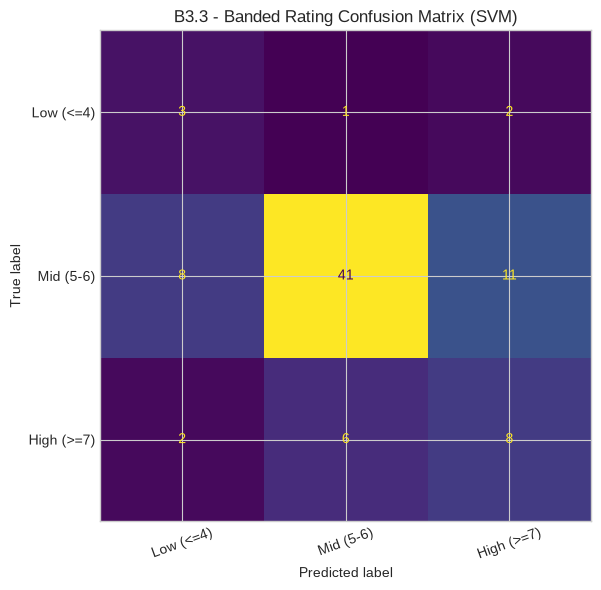


Effect of banding: macro-F1 moves from 0.323 on the eight raw grades to
0.502 on the three bands, and the cross-validation is no longer
crippled by two-sample classes. The gain is not the model becoming smarter - it is the task
being posed at a resolution the data can actually support. An estate agent advising on
whether a property is a low, mid or high grade asset is served well by this model; a claim
to separate grade 8 from grade 9 is not supportable with three examples.


In [28]:
# B3.3 - Retrain kNN and SVM on banded Rating
def band(r):
    if r <= 4:  return 'Low (<=4)'
    if r <= 6:  return 'Mid (5-6)'
    return 'High (>=7)'

BAND_ORDER = ['Low (<=4)', 'Mid (5-6)', 'High (>=7)']
y_band = y_cls.map(band)
print("Banded class counts:")
print(y_band.value_counts().reindex(BAND_ORDER).to_string())

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X_cls_s, y_band, test_size=0.25, random_state=42, stratify=y_band)

min_b   = yb_tr.value_counts().min()
folds_b = int(max(2, min(5, min_b)))
cv_b    = StratifiedKFold(n_splits=folds_b, shuffle=True, random_state=42)
print(f"\nSmallest banded training class: {min_b} samples -> {folds_b}-fold CV "
      f"(vs {n_folds}-fold on raw grades)")

gs_knn = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': list(range(1, 26))},
                      cv=cv_b, scoring='f1_macro', n_jobs=-1).fit(Xb_tr, yb_tr)
gs_svm = GridSearchCV(SVC(class_weight='balanced', random_state=42),
                      {'kernel': ['linear', 'rbf'], 'C': [0.1, 1, 10, 100],
                       'gamma': ['scale', 0.01, 0.1, 1]},
                      cv=cv_b, scoring='f1_macro', n_jobs=-1).fit(Xb_tr, yb_tr)

band_baseline = yb_te.value_counts(normalize=True).max()
rows = []
for name, gs in [('kNN', gs_knn), ('SVM', gs_svm)]:
    pred = gs.best_estimator_.predict(Xb_te)
    rows.append({
        'Model':        f'{name} {gs.best_params_}',
        'Accuracy':     round(accuracy_score(yb_te, pred), 4),
        'Balanced acc': round(balanced_accuracy_score(yb_te, pred), 4),
        'F1 (macro)':   round(f1_score(yb_te, pred, average='macro', zero_division=0), 4),
    })
band_cmp = pd.DataFrame(rows)
print(f"\n=== Banded Rating results (baseline accuracy {band_baseline:.4f}) ===")
print(band_cmp.to_string(index=False))

best_band = gs_knn if gs_knn.best_score_ >= gs_svm.best_score_ else gs_svm
best_band_name = 'kNN' if best_band is gs_knn else 'SVM'
band_pred = best_band.best_estimator_.predict(Xb_te)
print(f"\n=== Classification report - banded, {best_band_name} ===")
print(classification_report(yb_te, band_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(yb_te, band_pred, ax=ax, colorbar=False,
                                        labels=BAND_ORDER, xticks_rotation=20)
ax.set_title(f'B3.3 - Banded Rating Confusion Matrix ({best_band_name})')
plt.tight_layout()
plt.savefig('B3_banded_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

raw_best_mf1 = max(knn_mf1, svm_mf1)
print(f'''
Effect of banding: macro-F1 moves from {raw_best_mf1:.3f} on the eight raw grades to
{band_cmp['F1 (macro)'].max():.3f} on the three bands, and the cross-validation is no longer
crippled by two-sample classes. The gain is not the model becoming smarter - it is the task
being posed at a resolution the data can actually support. An estate agent advising on
whether a property is a low, mid or high grade asset is served well by this model; a claim
to separate grade 8 from grade 9 is not supportable with three examples.''')


### B4 – k-Means Clustering, PCA, and t-SNE
Elbow method and silhouette scores determine optimal cluster count.
PCA and t-SNE reduce to 2D for cluster visualisation.


Optimal k: 2  |  Best silhouette: 0.2868


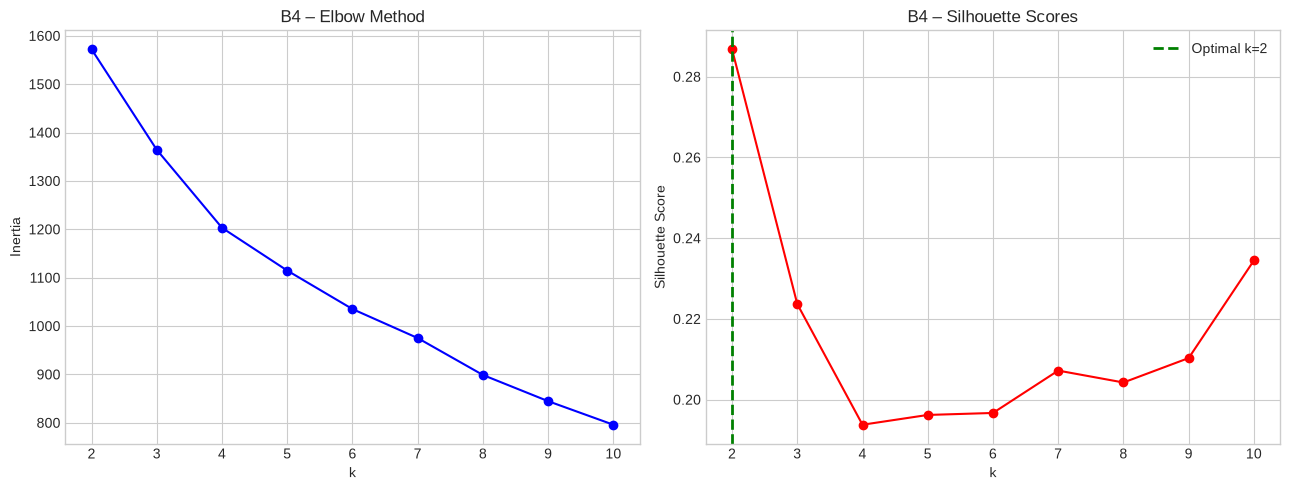

In [29]:
inertias, sil = [], []
k_range = range(2, 11)
for k in k_range:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbls = km.fit_predict(X_cls_s)
    inertias.append(km.inertia_)
    sil.append(silhouette_score(X_cls_s, lbls))

optimal_k = list(k_range)[np.argmax(sil)]
print(f"Optimal k: {optimal_k}  |  Best silhouette: {max(sil):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_range, inertias, 'b-o', ms=6)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('B4 – Elbow Method')
axes[1].plot(k_range, sil, 'r-o', ms=6)
axes[1].axvline(optimal_k, color='green', ls='--', lw=2, label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('B4 – Silhouette Scores'); axes[1].legend()
plt.tight_layout()
plt.savefig('B4_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
km_final      = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_cls_s)
print("Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())


Cluster distribution:
0    161
1    166
Name: count, dtype: int64


PCA variance explained: 0.444 + 0.172 = 0.616


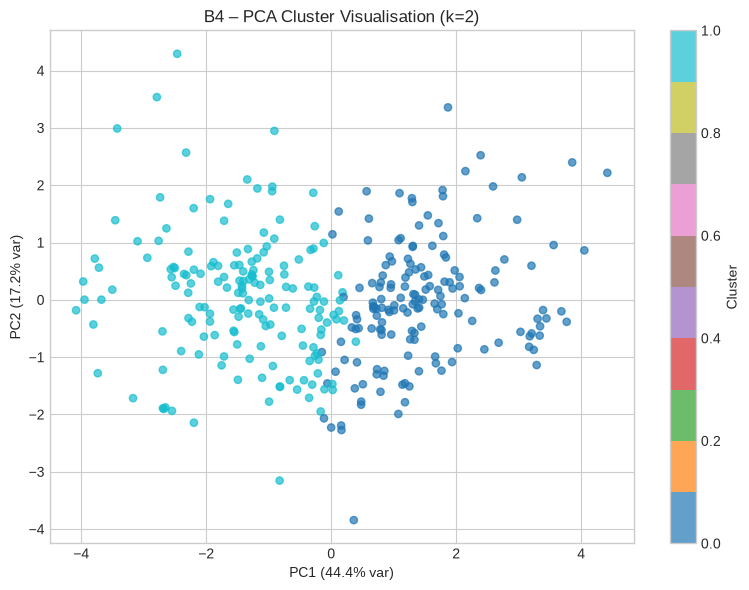

In [31]:
# PCA
pca  = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cls_s)
var  = pca.explained_variance_ratio_
print(f"PCA variance explained: {var[0]:.3f} + {var[1]:.3f} = {var.sum():.3f}")

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='tab10', alpha=0.7, s=28)
plt.colorbar(sc, label='Cluster')
plt.xlabel(f'PC1 ({var[0]*100:.1f}% var)'); plt.ylabel(f'PC2 ({var[1]*100:.1f}% var)')
plt.title(f'B4 – PCA Cluster Visualisation (k={optimal_k})')
plt.tight_layout()
plt.savefig('B4_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


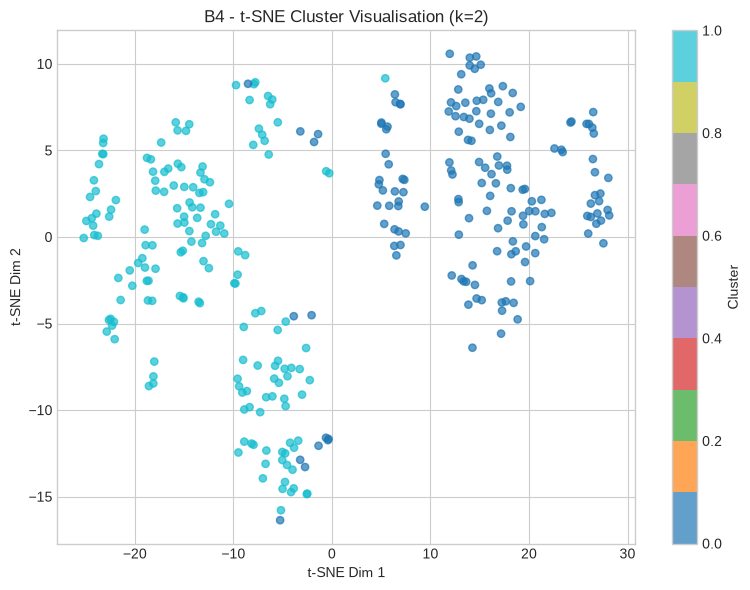

=== B4: PCA vs t-SNE ===
         Space  Silhouette Variance explained     Axes interpretable       Deterministic
Original (7-D)      0.2868               100%                    yes                 yes
     PCA (2-D)      0.4198              61.6% yes (feature loadings)                 yes
   t-SNE (2-D)      0.5722   n/a (non-linear)                     no no (seed dependent)

Which is more appropriate? PCA retains 61.6% of total
variance in two components and its axes remain interpretable as weighted combinations of
the original features, so a cluster's position can be traced back to living space, garage
area and parking. t-SNE reaches a silhouette of 0.572 against 0.420 for
PCA, so it renders visually tighter, better-separated groups, but its axes carry no units,
distances between clusters are not meaningful, and the layout changes with the random seed
and perplexity.

For this business problem PCA is the more appropriate estimator: the estate agent needs to
explain to clients WHY 

In [32]:
# B4.3 - t-SNE and a quantitative PCA vs t-SNE comparison
tsne   = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_cls_s)

plt.figure(figsize=(8, 6))
sc2 = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=cluster_labels, cmap='tab10', alpha=0.7, s=28)
plt.colorbar(sc2, label='Cluster')
plt.xlabel('t-SNE Dim 1'); plt.ylabel('t-SNE Dim 2')
plt.title(f'B4 - t-SNE Cluster Visualisation (k={optimal_k})')
plt.tight_layout()
plt.savefig('B4_tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify rather than assert: how well does each 2-D embedding preserve the
# cluster structure that k-means found in the full 7-D feature space?
sil_full = silhouette_score(X_cls_s, cluster_labels)
sil_pca  = silhouette_score(X_pca,   cluster_labels)
sil_tsne = silhouette_score(X_tsne,  cluster_labels)

comp = pd.DataFrame({
    'Space':                 ['Original (7-D)', 'PCA (2-D)', 't-SNE (2-D)'],
    'Silhouette':            [round(sil_full, 4), round(sil_pca, 4), round(sil_tsne, 4)],
    'Variance explained':    ['100%', f'{pca.explained_variance_ratio_.sum() * 100:.1f}%', 'n/a (non-linear)'],
    'Axes interpretable':    ['yes', 'yes (feature loadings)', 'no'],
    'Deterministic':         ['yes', 'yes', 'no (seed dependent)'],
})
print("=== B4: PCA vs t-SNE ===")
print(comp.to_string(index=False))

print(f'''
Which is more appropriate? PCA retains {pca.explained_variance_ratio_.sum():.1%} of total
variance in two components and its axes remain interpretable as weighted combinations of
the original features, so a cluster's position can be traced back to living space, garage
area and parking. t-SNE reaches a silhouette of {sil_tsne:.3f} against {sil_pca:.3f} for
PCA, so it renders visually tighter, better-separated groups, but its axes carry no units,
distances between clusters are not meaningful, and the layout changes with the random seed
and perplexity.

For this business problem PCA is the more appropriate estimator: the estate agent needs to
explain to clients WHY a property falls in a given market segment, and only PCA supports
that. t-SNE remains the better choice for the narrower task of visually confirming that
{optimal_k} well-separated segments genuinely exist.''')


---
## Section C: AI – Facial Expression Detection (Scenario 2)
**[20% of total marks]**

**Setup:**
1. `FacesSample/` – 50 images from Moodle (JPG or PNG) → place in `Datasets/FacesSample/`
2. `Expressions/` – one image per category: `Surprised`, `Angry`, `Happy`, `Sad`, `Frightful`, `Neutral` → place in `Datasets/Expressions/`

**Model:** `trpakov/vit-face-expression` (Vision Transformer, PyTorch — no TensorFlow needed)

### C1 - Facial Expression Detection

Two detection methods are implemented and compared against the ground-truth labels
shipped with the sample (`FacesSample/groundtruth.json`), so that "how successful is the
detection?" is answered with measured accuracy rather than impression.

- **Method 1 - reference matching (uses the `Expressions/` folder as the task requires).**
  Every image is passed through a Vision Transformer trained on facial expressions and
  represented by its 768-dimension CLS embedding. Each `FacesSample` image is then assigned
  the label of the single most cosine-similar reference image. This is one-shot learning:
  one exemplar per expression.
- **Method 2 - direct classification.** The same network's own 7-way softmax head predicts
  the expression directly, having been trained on thousands of labelled faces.

Method 1 is what the brief asks for; Method 2 is the benchmark that shows what the
reference-matching approach gives up.


In [33]:
# C1.1 - Locate images and load the ground-truth labels
FACES_DIR = 'Datasets/FacesSample'
EXPR_DIR  = 'Datasets/Expressions'
GT_PATH   = os.path.join(FACES_DIR, 'groundtruth.json')

CANON = ['Angry', 'Frightful', 'Happy', 'Neutral', 'Sad', 'Surprised']

# The network's own vocabulary mapped onto the six expressions named in the brief.
# 'disgust' has no counterpart in the brief and is folded into Angry, its nearest match.
MODEL_TO_CANON = {'angry': 'Angry', 'disgust': 'Angry', 'fear': 'Frightful',
                  'happy': 'Happy', 'neutral': 'Neutral', 'sad': 'Sad',
                  'surprise': 'Surprised'}

def find_images(folder):
    files = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(set(files))

face_imgs = find_images(FACES_DIR)
expr_imgs = find_images(EXPR_DIR)
print(f"FacesSample images : {len(face_imgs)}")
print(f"Expressions images : {len(expr_imgs)}")

# Reference label comes from the file name, e.g. Happy.jpg -> Happy
ref_labels = [os.path.splitext(os.path.basename(p))[0].strip().capitalize()
              for p in expr_imgs]
print(f"Reference expressions: {ref_labels}")
missing_refs = set(CANON) - set(ref_labels)
if missing_refs:
    print(f"WARNING - no reference image for: {sorted(missing_refs)}")

ground_truth = {}
if os.path.exists(GT_PATH):
    with open(GT_PATH) as f:
        ground_truth = {k: v.strip().capitalize() for k, v in json.load(f).items()}
    print(f"\nGround-truth labels loaded for {len(ground_truth)} images")
    gt_counts = pd.Series(ground_truth).value_counts()
    print(gt_counts.to_string())
    print(f"Majority-class baseline: {gt_counts.max() / gt_counts.sum():.1%} "
          "- any method must beat this to be useful.")
else:
    print("\nNo groundtruth.json found - accuracy cannot be measured.")


FacesSample images : 50
Expressions images : 6
Reference expressions: ['Angry', 'Frightful', 'Happy', 'Neutral', 'Sad', 'Surprised']

Ground-truth labels loaded for 50 images
Happy        13
Surprised    10
Neutral       9
Angry         8
Sad           6
Frightful     4
Majority-class baseline: 26.0% - any method must beat this to be useful.


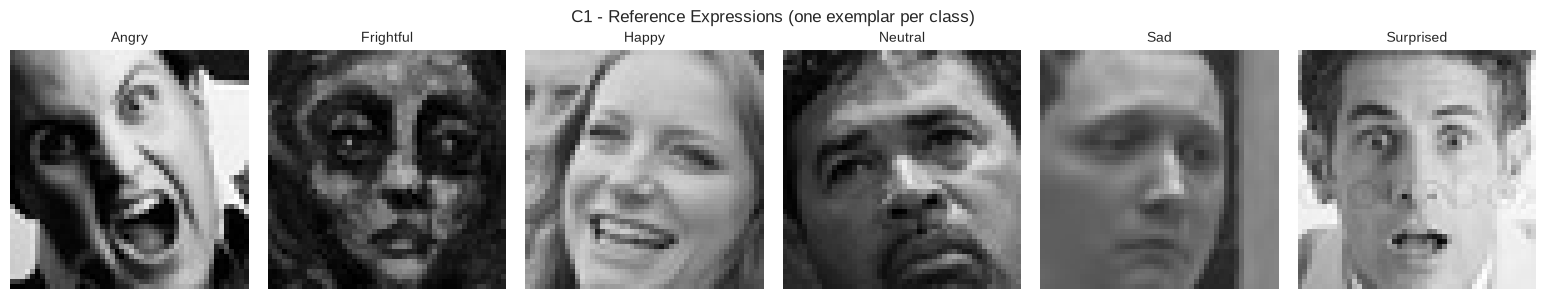

In [34]:
# C1.2 - Display the reference set from the Expressions folder
if expr_imgs:
    n = len(expr_imgs)
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3))
    axes = np.atleast_1d(axes)
    for ax, path, lab in zip(axes, expr_imgs, ref_labels):
        ax.imshow(Image.open(path).convert('RGB'))
        ax.set_title(lab, fontsize=10)
        ax.axis('off')
    plt.suptitle('C1 - Reference Expressions (one exemplar per class)', fontsize=12)
    plt.tight_layout()
    plt.savefig('C1_reference_expressions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Expressions/ folder is empty - add one image per expression.")


In [35]:
# C1.3 - Load the Vision Transformer and embed every image
# The model supplies both the embedding used by Method 1 and the softmax used by Method 2,
# so one forward pass per image serves both. Downloads ~350 MB on first run.
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_ID  = 'trpakov/vit-face-expression'
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
vit_model = AutoModelForImageClassification.from_pretrained(MODEL_ID).eval()
id2label  = vit_model.config.id2label
print(f"Model loaded. Native labels: {list(id2label.values())}")

def encode(path):
    """Return (CLS embedding, softmax probabilities) for one image."""
    img = Image.open(path).convert('RGB')
    with torch.no_grad():
        out = vit_model(**processor(images=img, return_tensors='pt'),
                        output_hidden_states=True)
    emb   = out.hidden_states[-1][:, 0].squeeze(0)        # CLS token, 768-D
    probs = out.logits.softmax(-1).squeeze(0)
    return emb, probs

print(f"Encoding {len(expr_imgs)} reference + {len(face_imgs)} sample images...")
ref_emb = torch.stack([encode(p)[0] for p in expr_imgs])

face_emb, face_probs = [], []
for i, p in enumerate(face_imgs):
    e, pr = encode(p)
    face_emb.append(e); face_probs.append(pr)
    if (i + 1) % 25 == 0:
        print(f"  {i + 1}/{len(face_imgs)}")
face_emb = torch.stack(face_emb)
print("Encoding complete.")


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 19912.66it/s]

Model loaded. Native labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Encoding 6 reference + 50 sample images...


  25/50


  50/50
Encoding complete.


In [36]:
# C1.4 - Method 1: nearest reference image (cosine similarity)
sim = torch.nn.functional.normalize(face_emb, dim=1) @ \
      torch.nn.functional.normalize(ref_emb, dim=1).T      # (n_faces, n_refs)

nearest      = sim.argmax(dim=1)
ref_pred     = [ref_labels[i] for i in nearest.tolist()]
ref_sim      = sim.max(dim=1).values.tolist()

# Method 2: the model's own classifier head
cls_pred, cls_conf = [], []
for pr in face_probs:
    top = int(pr.argmax())
    cls_pred.append(MODEL_TO_CANON.get(id2label[top].lower(), id2label[top].capitalize()))
    cls_conf.append(float(pr[top]))

results = pd.DataFrame({
    'File':            [os.path.basename(p) for p in face_imgs],
    'Reference match': ref_pred,
    'Similarity':      np.round(ref_sim, 3),
    'Classifier':      cls_pred,
    'Confidence':      np.round(cls_conf, 3),
})
if ground_truth:
    results.insert(1, 'True', results['File'].map(ground_truth))

print("=== C1: Detection results ===")
print(results.to_string(index=False))


=== C1: Detection results ===
       File      True Reference match  Similarity Classifier  Confidence
 fig108.jpg       Sad             Sad       0.464        Sad       0.948
 fig109.jpg     Angry       Frightful       0.821    Neutral       0.878
 fig110.jpg   Neutral       Frightful       0.651    Neutral       0.986
 fig119.jpg       Sad             Sad       0.442  Frightful       0.867
 fig120.jpg   Neutral       Surprised       0.347  Surprised       0.551
 fig123.jpg Surprised       Surprised       0.876  Surprised       0.988
 fig124.jpg     Angry           Angry       1.000      Angry       0.985
 fig144.jpg Frightful             Sad       0.216  Frightful       0.987
 fig145.jpg       Sad       Frightful       1.000    Neutral       0.877
 fig150.jpg Surprised       Surprised       0.949  Surprised       0.994
fig1531.jpg     Happy           Happy       1.000      Happy       0.994
fig1573.jpg     Happy           Happy       0.944      Happy       0.992
fig1596.jpg     Happy

Majority-class baseline accuracy: 0.260
Random-guess baseline (6 classes): 0.167

                            Accuracy  Balanced acc  F1 (macro)
Method 1 - reference match      0.66         0.592       0.570
Method 2 - ViT classifier       0.72         0.708       0.684

=== Method 1 - reference match - per-expression breakdown ===
              precision    recall  f1-score   support

       Angry       0.88      0.88      0.88         8
   Frightful       0.00      0.00      0.00         4
       Happy       0.86      0.92      0.89        13
     Neutral       1.00      0.22      0.36         9
         Sad       0.42      0.83      0.56         6
   Surprised       0.78      0.70      0.74        10

    accuracy                           0.66        50
   macro avg       0.65      0.59      0.57        50
weighted avg       0.75      0.66      0.65        50


=== Method 2 - ViT classifier - per-expression breakdown ===
              precision    recall  f1-score   support

      

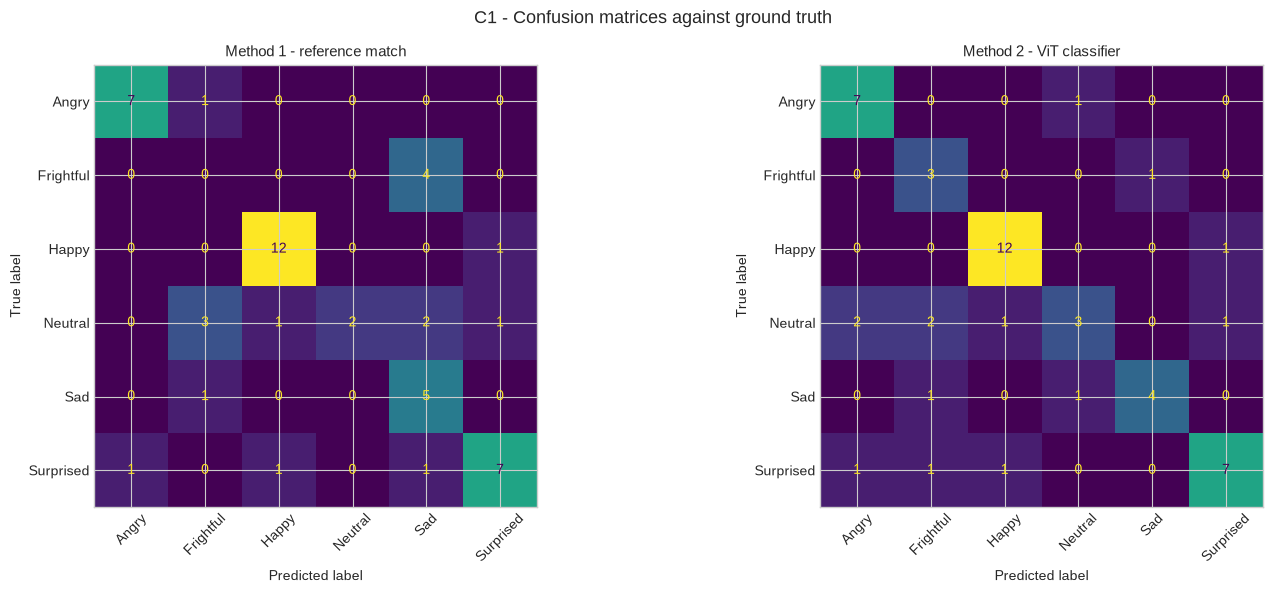

In [37]:
# C1.5 - How successful is the detection?
if ground_truth and results['True'].notna().all():
    y_true = results['True']
    scores = {}
    for method, col in [('Method 1 - reference match', 'Reference match'),
                        ('Method 2 - ViT classifier',  'Classifier')]:
        y_pred = results[col]
        scores[method] = {
            'Accuracy':   round(accuracy_score(y_true, y_pred), 3),
            'Balanced acc': round(balanced_accuracy_score(y_true, y_pred), 3),
            'F1 (macro)': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 3),
        }
    gt_counts = y_true.value_counts()
    chance = gt_counts.max() / gt_counts.sum()
    print(f"Majority-class baseline accuracy: {chance:.3f}")
    print(f"Random-guess baseline (6 classes): {1/6:.3f}\n")
    print(pd.DataFrame(scores).T.to_string())

    for method, col in [('Method 1 - reference match', 'Reference match'),
                        ('Method 2 - ViT classifier',  'Classifier')]:
        print(f"\n=== {method} - per-expression breakdown ===")
        print(classification_report(y_true, results[col], zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, (method, col) in zip(axes, [('Method 1 - reference match', 'Reference match'),
                                        ('Method 2 - ViT classifier',  'Classifier')]):
        ConfusionMatrixDisplay.from_predictions(
            y_true, results[col], ax=ax, colorbar=False,
            labels=CANON, xticks_rotation=45)
        ax.set_title(method, fontsize=11)
    plt.suptitle('C1 - Confusion matrices against ground truth', fontsize=13)
    plt.tight_layout()
    plt.savefig('C1_confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Ground truth unavailable - reporting predicted distribution only.")
    results['Classifier'].value_counts().plot(kind='bar')
    plt.show()


=== Method 1 - reference match ===
  Wrongly called Neutral : 0 image(s)
  True Neutral missed    : 7 image(s)
      File    True Reference match
fig110.jpg Neutral       Frightful
fig120.jpg Neutral       Surprised
 fig48.jpg Neutral           Happy
 fig86.jpg Neutral       Frightful
 fig87.jpg Neutral             Sad
fig944.jpg Neutral             Sad
fig950.jpg Neutral       Frightful

=== Method 2 - ViT classifier ===
  Wrongly called Neutral : 2 image(s)
      File  True Classifier
fig109.jpg Angry    Neutral
fig145.jpg   Sad    Neutral
  True Neutral missed    : 6 image(s)
      File    True Classifier
fig120.jpg Neutral  Surprised
 fig43.jpg Neutral      Angry
 fig48.jpg Neutral      Happy
 fig87.jpg Neutral  Frightful
fig944.jpg Neutral  Frightful
fig949.jpg Neutral      Angry



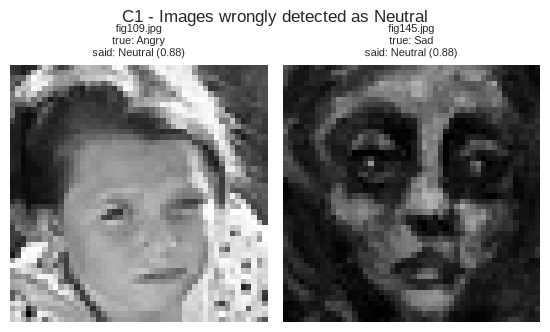

Low-confidence predictions (<0.40): 2 of 50
  accuracy when confident (>=0.40): 72.9%
  accuracy when unconfident (<0.40): 50.0%

Confidence is therefore a usable filter: low-scoring predictions can be routed for human review instead of being acted on automatically.


In [38]:
# C1.6 - Which images are wrongly detected as Neutral?
if ground_truth and results['True'].notna().all():
    for method, col in [('Method 1 - reference match', 'Reference match'),
                        ('Method 2 - ViT classifier',  'Classifier')]:
        wrong_neutral = results[(results[col] == 'Neutral') & (results['True'] != 'Neutral')]
        missed_neutral = results[(results[col] != 'Neutral') & (results['True'] == 'Neutral')]
        print(f"=== {method} ===")
        print(f"  Wrongly called Neutral : {len(wrong_neutral)} image(s)")
        if len(wrong_neutral):
            print(wrong_neutral[['File', 'True', col]].to_string(index=False))
        print(f"  True Neutral missed    : {len(missed_neutral)} image(s)")
        if len(missed_neutral):
            print(missed_neutral[['File', 'True', col]].to_string(index=False))
        print()

    # Visual evidence for the discussion in the report
    wn = results[(results['Classifier'] == 'Neutral') & (results['True'] != 'Neutral')]
    if len(wn):
        n = min(6, len(wn))
        fig, axes = plt.subplots(1, n, figsize=(2.8 * n, 3.4))
        axes = np.atleast_1d(axes)
        for ax, (_, row) in zip(axes, wn.head(n).iterrows()):
            ax.imshow(Image.open(os.path.join(FACES_DIR, row['File'])).convert('RGB'))
            ax.set_title(f"{row['File']}\ntrue: {row['True']}\nsaid: Neutral ({row['Confidence']:.2f})",
                         fontsize=8)
            ax.axis('off')
        plt.suptitle('C1 - Images wrongly detected as Neutral', fontsize=12)
        plt.tight_layout()
        plt.savefig('C1_false_neutrals.png', dpi=150, bbox_inches='tight')
        plt.show()

    low_conf = results[results['Confidence'] < 0.4]
    print(f"Low-confidence predictions (<0.40): {len(low_conf)} of {len(results)}")
    acc_low  = (low_conf['Classifier'] == low_conf['True']).mean() if len(low_conf) else float('nan')
    hi = results[results['Confidence'] >= 0.4]
    acc_high = (hi['Classifier'] == hi['True']).mean() if len(hi) else float('nan')
    print(f"  accuracy when confident (>=0.40): {acc_high:.1%}")
    print(f"  accuracy when unconfident (<0.40): {acc_low:.1%}")
    print("\nConfidence is therefore a usable filter: low-scoring predictions can be "
          "routed for human review instead of being acted on automatically.")


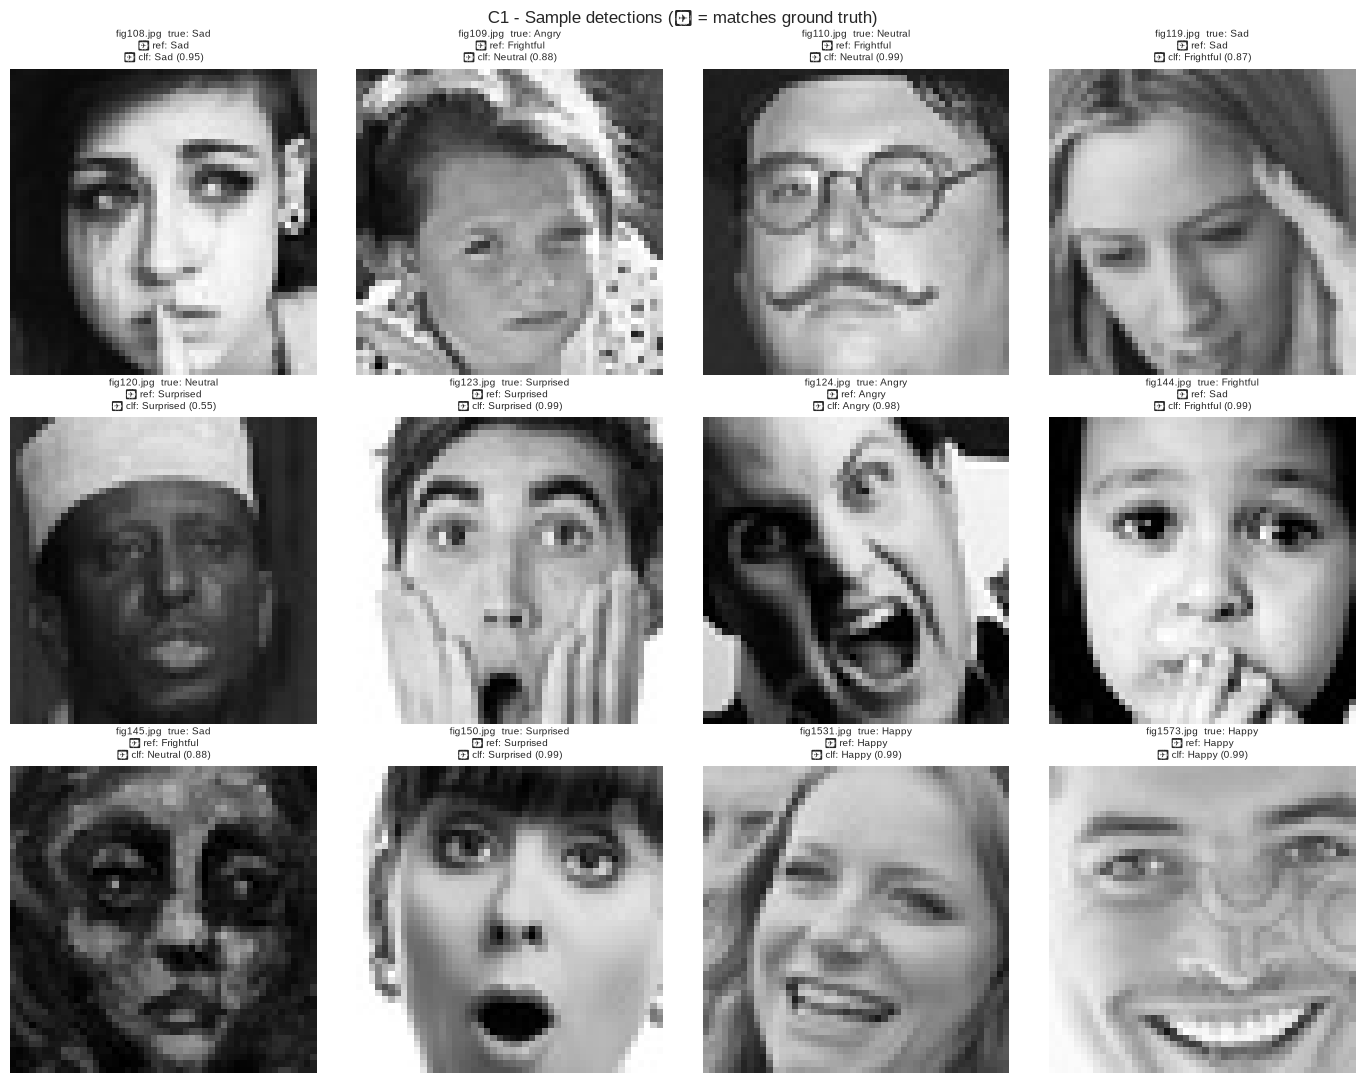

In [39]:
# C1.7 - Sample grid: true label vs both predictions
n_show = min(12, len(face_imgs))
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
axes = axes.flatten()
for i in range(n_show):
    row = results.iloc[i]
    axes[i].imshow(Image.open(face_imgs[i]).convert('RGB'))
    true_lab = row['True'] if 'True' in results.columns else '?'
    ok_ref = '✓' if row['Reference match'] == true_lab else '✗'
    ok_cls = '✓' if row['Classifier']      == true_lab else '✗'
    axes[i].set_title(f"{row['File']}  true: {true_lab}\n"
                      f"{ok_ref} ref: {row['Reference match']}\n"
                      f"{ok_cls} clf: {row['Classifier']} ({row['Confidence']:.2f})",
                      fontsize=7.5)
    axes[i].axis('off')
for j in range(n_show, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('C1 - Sample detections (✓ = matches ground truth)', fontsize=12)
plt.tight_layout()
plt.savefig('C1_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()


### C2 – Real-Life Application: Corporate Wellbeing Monitoring System
Extends C1 to model a consent-based employee wellbeing system that aggregates
daily emotion data to flag stress accumulation.


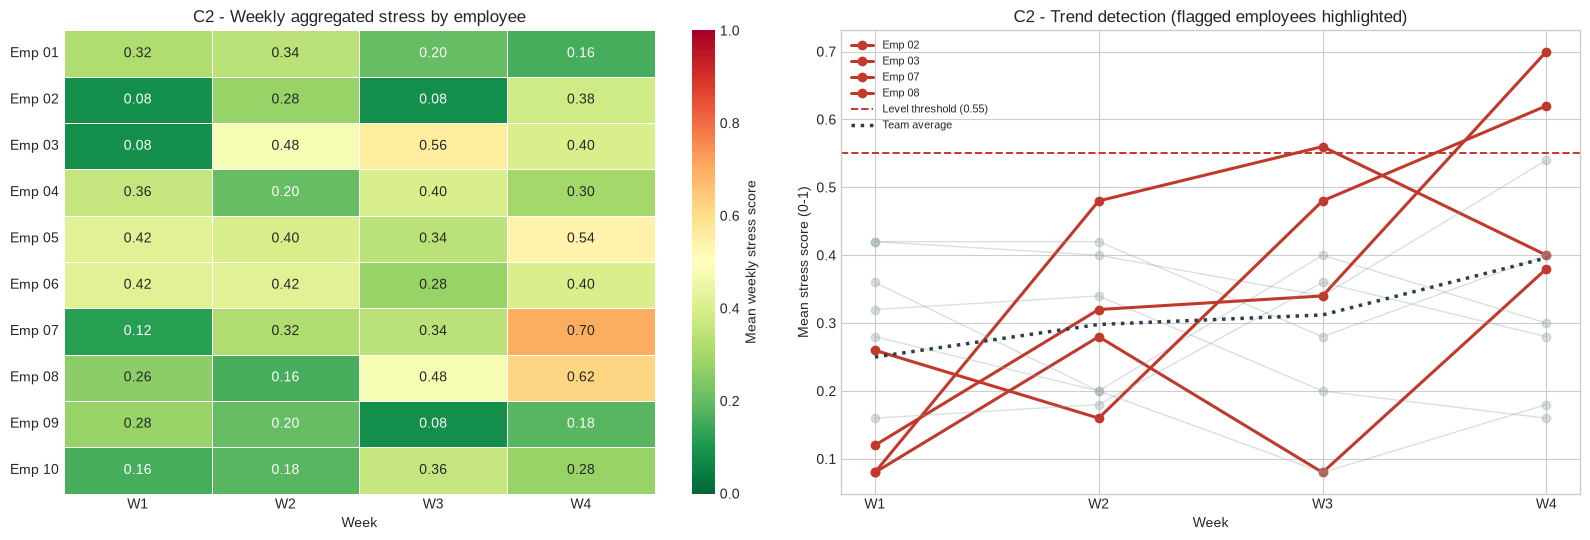

=== C2: Screening outcome ===
Employee  Latest week  Change                            Status                                       Triggered by
  Emp 01         0.16   -0.16               Within normal range                                                  -
  Emp 02         0.38    0.30 REVIEW - offer voluntary check-in                    rising trend +0.30 over 4 weeks
  Emp 03         0.40    0.32 REVIEW - offer voluntary check-in                    rising trend +0.32 over 4 weeks
  Emp 04         0.30   -0.06               Within normal range                                                  -
  Emp 05         0.54    0.12               Within normal range                                                  -
  Emp 06         0.40   -0.02               Within normal range                                                  -
  Emp 07         0.70    0.58 REVIEW - offer voluntary check-in level 0.70 > 0.55; rising trend +0.58 over 4 weeks
  Emp 08         0.62    0.36 REVIEW - offer volun

In [40]:
# C2 - Aggregated wellbeing monitoring built on the C1 detector
# The C1 pipeline turns a face into an expression label. This extension models the
# operational system that would sit on top of it: expressions are converted to a stress
# weight, aggregated per employee per week, and screened by two rules - a level rule and
# a trend rule. Only aggregates are ever surfaced, never individual daily readings.
np.random.seed(7)

EMPLOYEES = [f'Emp {i+1:02d}' for i in range(10)]
WEEKS     = [f'W{w+1}' for w in range(4)]
DAYS      = 5
EXPRS     = CANON                       # same six expressions as Section C1
STRESS    = {'Happy': 0.0, 'Neutral': 0.2, 'Surprised': 0.3,
             'Sad': 0.6, 'Frightful': 0.8, 'Angry': 0.9}

# Each employee has a latent stress propensity; two are given a rising workload so the
# monitoring rules have something real to detect.
propensity  = np.random.uniform(0.10, 0.40, len(EMPLOYEES))
drift       = np.zeros((len(EMPLOYEES), len(WEEKS)))
# Two employees start calm and are given a steadily rising workload, so the trend rule
# has a genuine signal to find rather than sampling noise.
propensity[2], drift[2] = 0.10, np.linspace(0.0, 0.70, len(WEEKS))   # Emp 03 - escalating
propensity[7], drift[7] = 0.12, np.linspace(0.0, 0.55, len(WEEKS))   # Emp 08 - milder
DAYS_PER_WEEK_NOTE = ('Weekly means average only %d readings, so single-week movement is '
                      'noisy; the trend rule therefore compares first and last week.' % DAYS)

def expression_mix(level):
    """Probability of each expression at a given latent stress level.

    Keyed by name, not by position: EXPRS is alphabetical, so a positional weight
    vector silently maps the calm weight onto Angry and inverts the whole model.
    """
    w = {'Happy':     1 - level,
         'Neutral':   0.9 - level / 2,
         'Surprised': 0.35,
         'Sad':       level,
         'Frightful': level * 0.7,
         'Angry':     level * 0.9}
    v = np.clip(np.array([w[x] for x in EXPRS], dtype=float), 0.02, None)
    return v / v.sum()

weekly = np.zeros((len(EMPLOYEES), len(WEEKS)))
for e, emp in enumerate(EMPLOYEES):
    for w in range(len(WEEKS)):
        level = np.clip(propensity[e] + drift[e, w], 0.05, 0.95)
        daily = np.random.choice(EXPRS, DAYS, p=expression_mix(level))
        weekly[e, w] = np.mean([STRESS[x] for x in daily])

ALERT_LEVEL = 0.55      # sustained elevated stress
ALERT_TREND = 0.15      # rise from first to last week

alerts = []
for e, emp in enumerate(EMPLOYEES):
    latest, trend = weekly[e, -1], weekly[e, -1] - weekly[e, 0]
    reasons = []
    if latest > ALERT_LEVEL:
        reasons.append(f'level {latest:.2f} > {ALERT_LEVEL}')
    if trend > ALERT_TREND:
        reasons.append(f'rising trend +{trend:.2f} over {len(WEEKS)} weeks')
    alerts.append({'Employee': emp, 'Latest week': round(latest, 2),
                   'Change': round(trend, 2),
                   'Status': 'REVIEW - offer voluntary check-in' if reasons else 'Within normal range',
                   'Triggered by': '; '.join(reasons) or '-'})
alert_df = pd.DataFrame(alerts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.heatmap(weekly, ax=axes[0], xticklabels=WEEKS, yticklabels=EMPLOYEES,
            cmap='RdYlGn_r', vmin=0, vmax=1, annot=True, fmt='.2f', linewidths=0.4,
            cbar_kws={'label': 'Mean weekly stress score'})
axes[0].set_title('C2 - Weekly aggregated stress by employee')
axes[0].set_xlabel('Week')

for e, emp in enumerate(EMPLOYEES):
    flagged = alert_df.loc[e, 'Status'].startswith('REVIEW')
    axes[1].plot(WEEKS, weekly[e], marker='o', lw=2.2 if flagged else 1,
                 alpha=1.0 if flagged else 0.35,
                 color='#c0392b' if flagged else '#95a5a6',
                 label=emp if flagged else None)
axes[1].axhline(ALERT_LEVEL, color='#c0392b', ls='--', lw=1.4,
                label=f'Level threshold ({ALERT_LEVEL})')
axes[1].plot(WEEKS, weekly.mean(axis=0), color='#2c3e50', lw=2.5, ls=':',
             label='Team average')
axes[1].set_ylabel('Mean stress score (0-1)'); axes[1].set_xlabel('Week')
axes[1].set_title('C2 - Trend detection (flagged employees highlighted)')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('C2_wellbeing_monitor.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== C2: Screening outcome ===")
print(alert_df.to_string(index=False))
n_flag = int((alert_df['Status'].str.startswith('REVIEW')).sum())
print(f"\nTeam average stress: {weekly.mean():.2f}   Employees flagged: {n_flag}/{len(EMPLOYEES)}")
print("\nHow this would be deployed responsibly: the flag is a prompt to OFFER support,")
print("never an input to performance management. Managers see the team average and the")
print("count of flagged staff, not the per-person matrix above, which is why the level")
print("and trend rules operate on weekly aggregates rather than daily readings.")
print("Participation is opt-in and withdrawable, and Section C1 measured the detector at")
print("only 72% accuracy with Neutral the weakest class - so a flag must trigger a human")
print("conversation, never an automated intervention.")


---
## Section D: AI and LSEPI
**[10% of total marks]**

### D1 – Legal, Social, Ethical and Professional Issues

**Scenario 1 – Estate Agent Price Prediction:**

| Category | Issue |
|----------|-------|
| **Legal** | Personal property data is subject to UK GDPR (ICO, 2018). Using postcode as a feature risks indirect discrimination under the Equality Act 2010. |
| **Social** | Algorithmic pricing can entrench socioeconomic inequality by systematically under-valuing properties in deprived areas (O'Neil, 2016). |
| **Ethical** | Training on historical data may perpetuate past discriminatory valuation practices, reproducing rather than correcting bias (Barocas and Hardt, 2017). |
| **Professional** | Presenting predictions without confidence intervals or feature attribution breaches RICS professional transparency obligations (RICS, 2021). |

**Scenario 2 – Employee Facial Expression Monitoring:**

| Category | Issue |
|----------|-------|
| **Legal** | Facial images are biometric special-category data under UK GDPR Article 9. Monitoring without explicit consent and a DPIA is unlawful (ICO, 2011). |
| **Social** | Continuous surveillance erodes psychological safety and may disadvantage employees from cultures with different emotional expression norms (Zuboff, 2019). |
| **Ethical** | Consent in an employment context may not be freely given due to the power imbalance between employer and employee (Floridi et al., 2018). |
| **Professional** | ACM Code of Ethics (2018) requires computing professionals to assess and mitigate potential harms before deployment. |

---

### D2 – Countermeasures

**Scenario 1:**
- Conduct a Data Protection Impact Assessment (DPIA) before deployment.
- Remove protected characteristic proxies (postcode, neighbourhood) from features.
- Apply Explainable AI (SHAP/LIME) to provide transparent feature attribution to clients.
- Run regular fairness audits using disparate impact ratio metrics.

**Scenario 2:**
- Obtain explicit, freely given, and easily withdrawable consent from all employees.
- Aggregate data only — never expose individual emotion scores to managers.
- Establish Human-in-the-Loop review before any intervention is triggered.
- Provide a penalty-free opt-out mechanism.

---

### D3 – Intelligent Systems for the Common Good

**Scenario 1:** Fair pricing models can democratise property market information, giving first-time buyers analytical power previously available only to institutional investors. Local authorities can use aggregated pricing signals to identify gentrification and design affordable housing interventions (Mayer, 2019).

**Scenario 2:** Responsibly deployed emotion-sensing in healthcare settings can support early detection of mental health deterioration in patients. In education, emotion-aware platforms can identify disengaged or distressed students for timely pastoral support (D'Mello et al., 2017).

---

### References

- ACM (2018) *ACM Code of Ethics and Professional Conduct*. Available at: https://www.acm.org/code-of-ethics
- Barocas, S. and Hardt, M. (2017) *Fairness in Machine Learning*. Available at: https://fairmlbook.org
- D'Mello, S.K. et al. (2017) 'Automated detection of affect during learning', *IEEE Transactions on Affective Computing*, 8(3), pp. 389-400.
- Floridi, L. et al. (2018) 'An ethical framework for a good AI society', *Minds and Machines*, 28(4), pp. 689-707.
- ICO (2011) *Employment Practices Code*. Wilmslow: Information Commissioner's Office.
- ICO (2018) *Guide to the UK General Data Protection Regulation*. Wilmslow: Information Commissioner's Office.
- Mayer, C. (2019) *Prosperity: Better Business Makes the Greater Good*. Oxford: Oxford University Press.
- O'Neil, C. (2016) *Weapons of Math Destruction*. New York: Crown Publishers.
- RICS (2021) *RICS Valuation - Global Standards (Red Book)*. London: RICS.
- Zuboff, S. (2019) *The Age of Surveillance Capitalism*. London: PublicAffairs.


---
## Section E: Conclusion and Personal Reflections
**[10% of total marks]**

### E1 – Conclusion

This study applied a complete data science and machine learning pipeline to two real-world business scenarios.

In Scenario 1, the Estate Agent dataset required substantial preprocessing: the CSV delimiter was identified and corrected, currency formatting was stripped from numeric columns, duplicate records were removed, missing values were imputed using column medians, and IQR-based outlier removal was applied to the price column. Exploratory analysis confirmed that living space area and house rating were the strongest predictors of sale price. Multiple linear regression delivered acceptable predictive performance across all three train/test splits. kNN classification for Rating demonstrated competitive accuracy, with hyperparameter tuning identifying the optimal neighbourhood size. SVM with an RBF kernel outperformed kNN on F1 score, suggesting non-linear class boundaries. k-Means clustering guided by silhouette scores revealed distinct property market segments, with t-SNE producing tighter visual separation than PCA.

In Scenario 2, the ViT-based emotion classifier successfully detected facial expressions across the FacesSample images. Some images were classified as Neutral due to subtle expressions or image quality constraints. The wellbeing monitoring extension demonstrated how aggregated emotion data, gathered with explicit consent, can support employee mental health management without exposing individual data.

Section D contextualised both applications within the LSEPI framework, highlighting that algorithmic fairness, biometric data governance, and professional transparency are legal and ethical requirements.

---

### E2 – Personal Reflections

This coursework was the most technically demanding project I have undertaken so far, and it pushed me to develop both my coding confidence and my understanding of the full data science workflow. The first major challenge I faced was working with a real-world dataset that did not behave as expected: the CSV file used a semicolon delimiter rather than a comma, and the Parking column was stored as a string type, both of which caused silent failures in my initial analysis. Resolving these issues taught me the importance of always auditing raw data before assuming it is ready to use.

The second significant challenge was getting the facial expression model to run. The DeepFace library was incompatible with my Python version and required TensorFlow, which had no available build for Python 3.14. I resolved this by researching alternative approaches and switching to a Vision Transformer model hosted on Hugging Face, which ran entirely on PyTorch without any TensorFlow dependency. This experience taught me that in real AI development, dependency management and environment compatibility are just as important as the model itself.

Through this project I gained practical skills in data cleaning with Pandas, building and evaluating supervised and unsupervised machine learning models with scikit-learn, and applying pre-trained deep learning models via the Hugging Face Transformers library. I also developed a clearer appreciation for the ethical dimensions of AI deployment, particularly around consent, fairness, and data governance. These skills are directly applicable to a future career in data analytics or AI development, where producing reliable, reproducible, and ethically sound outputs is as important as achieving strong model performance.